# DSA210 Term Project - EDA & Hypothesis Tests
## Alcohol Consumption and Traffic Accidents in Turkey
**Date:** April 2026

---
### Project Aim
Investigate whether regions in Turkey with higher alcohol consumption rates
also exhibit higher traffic-accident rates per 100 000 population, using:
- Traffic accident data (General Directorate of Security) - full year **2025** + Q1 **2026**
- Regional alcohol consumption rates (TurkStat Turkey Saglik Arastirmasi **2022**)
- Province population estimates (TURKSTAT Population Projections **2025**)

> **Data limitation note:** TurkStat's Health Survey publishes alcohol-consumption
> statistics at the **IBBS1 level** (12 statistical regions), not at the individual
> province level. Therefore this analysis is conducted at both the regional level
> (n=12) and the province level (n=81), where each province inherits its region's
> alcohol rate. Istanbul is its own IBBS1 region (TR1) and is analyzed individually.

---
### Contents
| Section | Description |
|---------|-------------|
| 0 | Imports & Settings |
| 1 | Data Collection |
| 2 | Data Merging & Feature Engineering |
| 3 | Exploratory Data Analysis |
| 4 | Hypothesis Testing (6 tests) |
| 5 | Summary of Results |


## 0. Imports & Settings

In [35]:
# Standard library
import warnings

# Third-party: data manipulation
import pandas as pd        # DataFrames and tabular data operations
import numpy as np         # Numerical arrays and mathematical operations

# Third-party: visualisation
import matplotlib.pyplot as plt           # Core plotting engine
import matplotlib.ticker as mticker       # Custom axis tick formatters
import seaborn as sns                     # Statistical visualisation (heatmaps)

# Third-party: statistical testing
from scipy import stats    # T-test, ANOVA, Mann-Whitney, Kruskal-Wallis,
                           # Wilcoxon, Chi-Square, linregress

# Notebook display helpers
from IPython.display import display

# Suppress benign deprecation warnings for cleaner output
warnings.filterwarnings('ignore')

# Plot style and shared colour palette
plt.style.use('seaborn-v0_8')
plt.rcParams.update({'figure.dpi': 130, 'figure.figsize': (12, 5)})

ACCENT = '#E63946'   # Red  -- used for highlights / second axis
BLUE   = '#457B9D'   # Blue -- used for primary bars / scatter
GREEN  = '#2A9D8F'   # Teal -- used for secondary comparisons


def display_full(obj):
    """
    Display a pandas DataFrame or Series with all rows and columns visible.

    By default Jupyter truncates large DataFrames. This helper temporarily
    overrides those display limits so the full table is always printed,
    which is useful for the 81-province dataset.

    Parameters
    ----------
    obj : pd.DataFrame or pd.Series
    """
    with pd.option_context(
        'display.max_rows',    None,
        'display.max_columns', None,
        'display.width',       None,
        'display.max_colwidth', None
    ):
        display(obj)


## 1. Data Collection

All datasets were manually transcribed from official PDF publications
because no machine-readable export was available from the source agencies.

| Dataset | Source | Year | Granularity |
|---------|--------|------|-------------|
| Traffic accidents | Emniyet Genel Mudurlugu (EGM) | 2025 full year | 81 provinces |
| Traffic accidents | Emniyet Genel Mudurlugu (EGM) | 2026 Q1 | 81 provinces |
| Province population | TURKSTAT Population Projections | 2025 | 81 provinces |
| Alcohol consumption | TurkStat Turkey Saglik Arastirmasi | 2022 | 12 IBBS1 regions |

### 1.1 Traffic Accidents - Full Year 2025 (per Province)
Source: *General Directorate of Security - Traffic Services Presidency*, December 2025 bulteni


In [36]:
# 2025 full-year traffic accident data (81 provinces)
#
# Column definitions:
#   injury_fatal_accidents    -- accidents that resulted in at least one injury
#                                or fatality (combined in EGM reporting)
#   material_damage_accidents -- accidents with only property damage (no injuries)
#   fatalities                -- number of people killed
#   injured                   -- number of people injured
#
# Provinces are listed in Turkish alphabetical order, matching the EGM bulletin.

data_2025 = {
    'province': [
        'Adana','Adiyaman','Afyonkarahisar','Agri','Amasya','Ankara','Antalya',
        'Artvin','Aydin','Balikesir','Bilecik','Bingol','Bitlis','Bolu','Burdur',
        'Bursa','Canakkale','Cankiri','Corum','Denizli','Diyarbakir','Edirne',
        'Elazig','Erzincan','Erzurum','Eskisehir','Gaziantep','Giresun',
        'Gumushane','Hakkari','Hatay','Isparta','Mersin','Istanbul','Izmir',
        'Kars','Kastamonu','Kayseri','Kirklareli','Kirsehir','Kocaeli','Konya',
        'Kutahya','Malatya','Manisa','Kahramanmaras','Mardin','Mugla','Mus',
        'Nevsehir','Nigde','Ordu','Rize','Sakarya','Samsun','Siirt','Sinop',
        'Sivas','Tekirdag','Tokat','Trabzon','Tunceli','Sanliurfa','Usak','Van',
        'Yozgat','Zonguldak','Aksaray','Bayburt','Karaman','Kirikkale','Batman',
        'Sirnak','Bartin','Ardahan','Igdir','Yalova','Karabuk','Kilis','Osmaniye','Duzce'
    ],
    'injury_fatal_accidents': [
        6765,2234,2871,947,1699,17540,14241,340,6035,5721,1026,820,782,1117,
        1467,10290,2499,853,2443,4621,3694,1277,1476,1098,1670,3177,6526,1280,
        423,318,7986,2166,8646,39253,15509,572,1214,5248,1166,898,7823,9297,
        2132,2610,6526,4487,1737,7193,544,1676,1583,2918,1151,4373,5621,830,
        919,2124,3968,2628,2539,253,4398,1562,2038,1389,1884,1593,233,1187,
        1240,1573,988,657,169,518,1485,992,705,3253,1549
    ],
    'material_damage_accidents': [
        6757,1776,3185,1123,1475,78863,12376,489,4016,4969,793,702,823,1351,
        965,19435,1867,997,3197,5726,4368,1321,1688,1447,2942,3465,5315,1323,
        526,244,3932,1073,4981,67960,26713,679,1256,4630,1247,1000,10817,10111,
        1824,2082,5619,3341,1547,5396,633,1768,1798,3843,1377,3950,7144,747,
        703,1918,5650,1812,3506,269,4060,1665,2650,1283,1687,2918,187,834,
        1494,1823,737,439,279,548,1198,772,191,1699,1139
    ],
    'fatalities': [
        71,23,24,7,20,159,98,7,59,73,14,7,5,13,19,58,41,10,19,63,36,18,
        15,9,26,18,60,24,5,7,54,22,102,134,122,9,28,45,13,8,37,108,22,
        34,87,50,25,57,4,19,35,15,13,39,36,5,9,41,31,26,19,2,52,21,26,
        32,10,26,2,6,13,4,13,6,3,9,7,14,1,25,12
    ],
    'injured': [
        9372,3400,4863,1739,2722,23717,19040,518,8211,8148,1593,1527,1462,
        1799,2286,13721,3455,1460,3880,6357,6122,1745,2449,1650,2918,4361,
        9784,1962,745,673,11283,3245,11769,47861,19643,949,2015,7902,1804,
        1420,10309,13846,3249,4026,9256,7084,2872,9849,972,2613,2422,4144,
        1650,6101,7762,1159,1456,3787,5288,4120,3608,442,7091,2349,3416,
        2363,2719,2550,368,1670,1907,2395,1583,1021,296,720,1958,1437,1065,4605,2254
    ]
}

# Convert to DataFrame and use 1-based index to match EGM bulletin row numbers
df_2025 = pd.DataFrame(data_2025)
df_2025.index = df_2025.index + 1
df_2025.index.name = 'No'

print(f'2025 dataset: {len(df_2025)} provinces')
print(f'Total injury/fatal accidents : {df_2025["injury_fatal_accidents"].sum():,}')
print(f'Total fatalities             : {df_2025["fatalities"].sum():,}')
print(f'Total injured                : {df_2025["injured"].sum():,}')
display_full(df_2025)


2025 dataset: 81 provinces
Total injury/fatal accidents : 288,253
Total fatalities             : 2,541
Total injured                : 407,352


,province,injury_fatal_accidents,material_damage_accidents,fatalities,injured
No,,,,,
1,Adana,6765,6757,71,9372
2,Adiyaman,2234,1776,23,3400
3,Afyonkarahisar,2871,3185,24,4863
4,Agri,947,1123,7,1739
5,Amasya,1699,1475,20,2722
6,Ankara,17540,78863,159,23717
7,Antalya,14241,12376,98,19040
8,Artvin,340,489,7,518
9,Aydin,6035,4016,59,8211


### 1.2 Traffic Accidents - Q1 2026 (January-March, per Province)
Source: *General Directorate of Security - March 2026 bulteni*

Q1 data is used for two purposes:
1. Year-over-year trend comparison (H5 - Wilcoxon Signed-Rank Test).
2. Conservative lower-bound projection of the 2026 annual total (Q1 x 4).

> **Why a lower bound?** Q1 (January-March) is historically Turkey's
> lowest-traffic quarter. Multiplying by 4 under-estimates the full year
> because summer months (May-September) produce significantly more accidents.


In [37]:
# Q1 2026 traffic accident data (81 provinces)
# Same structure and column definitions as df_2025 above.

data_2026_q1 = {
    'province': [
        'Adana','Adiyaman','Afyonkarahisar','Agri','Amasya','Ankara','Antalya',
        'Artvin','Aydin','Balikesir','Bilecik','Bingol','Bitlis','Bolu','Burdur',
        'Bursa','Canakkale','Cankiri','Corum','Denizli','Diyarbakir','Edirne',
        'Elazig','Erzincan','Erzurum','Eskisehir','Gaziantep','Giresun',
        'Gumushane','Hakkari','Hatay','Isparta','Mersin','Istanbul','Izmir',
        'Kars','Kastamonu','Kayseri','Kirklareli','Kirsehir','Kocaeli','Konya',
        'Kutahya','Malatya','Manisa','Kahramanmaras','Mardin','Mugla','Mus',
        'Nevsehir','Nigde','Ordu','Rize','Sakarya','Samsun','Siirt','Sinop',
        'Sivas','Tekirdag','Tokat','Trabzon','Tunceli','Sanliurfa','Usak','Van',
        'Yozgat','Zonguldak','Aksaray','Bayburt','Karaman','Kirikkale','Batman',
        'Sirnak','Bartin','Ardahan','Igdir','Yalova','Karabuk','Kilis','Osmaniye','Duzce'
    ],
    'injury_fatal_accidents': [
        1440,321,520,170,295,3706,2691,51,1178,1038,170,147,144,208,265,2148,
        432,167,426,867,694,250,301,142,305,611,1146,229,53,49,1460,405,1738,
        8733,3063,86,195,977,228,138,1669,1676,396,396,1221,654,339,1268,85,
        234,276,554,237,801,1157,127,172,313,806,442,533,31,861,291,299,
        231,397,294,28,185,250,263,214,143,20,84,274,172,88,630,284
    ],
    'material_damage_accidents': [
        2003,471,799,355,385,20708,2838,120,1009,1140,179,270,290,342,208,5207,
        395,249,844,1398,1545,337,484,317,896,817,1458,355,112,92,1193,259,1254,
        17915,6885,207,312,1185,322,202,2855,2441,436,532,1503,1015,465,1175,
        187,509,464,964,284,1046,1796,217,148,482,1640,475,800,88,1200,385,
        646,354,465,629,39,209,390,566,235,137,77,151,286,165,30,460,310
    ],
    'fatalities': [
        12,4,1,1,3,29,18,3,6,15,1,2,6,3,10,12,1,2,0,12,2,5,3,0,5,10,
        14,6,1,1,6,4,20,42,13,0,5,3,1,0,4,6,4,4,9,6,5,7,0,5,9,1,2,
        8,12,0,2,3,5,3,3,0,11,1,3,1,2,2,0,2,0,5,3,0,0,0,2,2,0,1,5
    ],
    'injured': [
        1967,525,874,316,459,5063,3584,75,1609,1517,249,269,273,350,415,2874,
        606,287,679,1193,1168,347,506,215,531,867,1711,322,87,111,2026,656,
        2310,10693,3877,205,338,1534,353,206,2243,2580,596,582,1666,1062,623,
        1665,128,374,421,775,311,1144,1636,184,263,533,1083,713,752,44,1445,
        439,447,391,601,492,62,265,352,390,338,242,28,115,367,282,124,893,415
    ]
}

df_2026q1 = pd.DataFrame(data_2026_q1)
df_2026q1.index = df_2026q1.index + 1
df_2026q1.index.name = 'No'

print(f'2026 Q1 dataset: {len(df_2026q1)} provinces')
print(f'Total injury/fatal accidents (Q1 2026): {df_2026q1["injury_fatal_accidents"].sum():,}')
print(f'Total fatalities (Q1 2026)             : {df_2026q1["fatalities"].sum():,}')
display_full(df_2026q1)


2026 Q1 dataset: 81 provinces
Total injury/fatal accidents (Q1 2026): 55,582
Total fatalities (Q1 2026)             : 420


,province,injury_fatal_accidents,material_damage_accidents,fatalities,injured
No,,,,,
1,Adana,1440,2003,12,1967
2,Adiyaman,321,471,4,525
3,Afyonkarahisar,520,799,1,874
4,Agri,170,355,1,316
5,Amasya,295,385,3,459
6,Ankara,3706,20708,29,5063
7,Antalya,2691,2838,18,3584
8,Artvin,51,120,3,75
9,Aydin,1178,1009,6,1609


### 1.3 Province Population - 2025
Source: *TURKSTAT Population Projections 2025*


In [38]:
# Province population estimates from TURKSTAT Population Projections 2025

# Population figures are used to normalise raw accident counts into rates
# (accidents per 100 000 people), making provinces of different sizes
# directly comparable. Without normalisation, large cities like Istanbul
# would always dominate the rankings simply due to their size.

pop_data = {
    'province': [
        'Adana','Adiyaman','Afyonkarahisar','Agri','Amasya','Ankara','Antalya',
        'Artvin','Aydin','Balikesir','Bilecik','Bingol','Bitlis','Bolu','Burdur',
        'Bursa','Canakkale','Cankiri','Corum','Denizli','Diyarbakir','Edirne',
        'Elazig','Erzincan','Erzurum','Eskisehir','Gaziantep','Giresun',
        'Gumushane','Hakkari','Hatay','Isparta','Mersin','Istanbul','Izmir',
        'Kars','Kastamonu','Kayseri','Kirklareli','Kirsehir','Kocaeli','Konya',
        'Kutahya','Malatya','Manisa','Kahramanmaras','Mardin','Mugla','Mus',
        'Nevsehir','Nigde','Ordu','Rize','Sakarya','Samsun','Siirt','Sinop',
        'Sivas','Tekirdag','Tokat','Trabzon','Tunceli','Sanliurfa','Usak','Van',
        'Yozgat','Zonguldak','Aksaray','Bayburt','Karaman','Kirikkale','Batman',
        'Sirnak','Bartin','Ardahan','Igdir','Yalova','Karabuk','Kilis','Osmaniye','Duzce'
    ],
    'population_2025': [
        2266381,607593,753047,493126,340490,5886877,2771976,171614,1179886,
        1283557,234445,287295,356977,335200,278814,3231385,571948,184888,
        543835,1075898,1844333,421574,604411,242429,777027,944243,2332252,
        462621,144370,271925,1469561,450256,1981455,16018524,4597279,270154,
        384578,1474196,395792,250808,2152335,2374558,569189,788618,1468388,
        1046432,936804,1088421,394681,316413,376254,761963,344033,1117128,
        1400928,354799,214526,637326,1227848,610873,828166,83365,2300886,
        399604,1149087,407652,585223,458978,86047,270257,284062,674295,
        602024,207673,91278,212708,316266,255149,157652,560036,418025
    ]
}

df_pop = pd.DataFrame(pop_data)
df_pop.index = df_pop.index + 1
df_pop.index.name = 'No'

print(f'Total Turkey population (81 provinces): {df_pop["population_2025"].sum():,.0f}')
display_full(df_pop.sort_values('population_2025', ascending=False))

Total Turkey population (81 provinces): 86,722,970


,province,population_2025
No,,
34,Istanbul,16018524
6,Ankara,5886877
35,Izmir,4597279
16,Bursa,3231385
7,Antalya,2771976
42,Konya,2374558
27,Gaziantep,2332252
63,Sanliurfa,2300886
1,Adana,2266381


### 1.4 Province -> IBBS1 Region Mapping
Source: *TurkStat Statistical Regional Units Classification (IBBS) Level 1*


In [39]:
# IBBS1 (Level-1 Statistical Regions) province mapping
#
# Turkey is divided into 12 IBBS1 regions by TurkStat for statistical reporting.
# This mapping is used because alcohol data is only available at the IBBS1 level
# (the finest geographic granularity published in the Health Survey).
#
# Key consequence for the analysis:
#   - All provinces in the same IBBS1 region share a single alcohol rate.
#   - Province-level tests therefore carry an ecological fallacy risk:
#     the regional average may not reflect individual province behaviour.

ibbs1_map = {
    'TR1 Istanbul'              : ['Istanbul'],
    'TR2 West Marmara'          : ['Tekirdag','Edirne','Kirklareli','Balikesir','Canakkale'],
    'TR3 Aegean'                : ['Izmir','Aydin','Denizli','Mugla','Manisa',
                                   'Afyonkarahisar','Kutahya','Usak'],
    'TR4 East Marmara'          : ['Bursa','Eskisehir','Bilecik','Kocaeli',
                                   'Sakarya','Duzce','Bolu','Yalova'],
    'TR5 West Anatolia'         : ['Ankara','Konya','Karaman'],
    'TR6 Mediterranean'         : ['Antalya','Isparta','Burdur','Adana','Mersin',
                                   'Hatay','Kahramanmaras','Osmaniye'],
    'TR7 Central Anatolia'      : ['Kirikkale','Aksaray','Nigde','Nevsehir',
                                   'Kirsehir','Kayseri','Sivas','Yozgat'],
    'TR8 West Black Sea'        : ['Zonguldak','Karabuk','Bartin','Kastamonu',
                                   'Cankiri','Sinop','Samsun','Tokat','Corum','Amasya'],
    'TR9 East Black Sea'        : ['Trabzon','Ordu','Giresun','Rize','Artvin','Gumushane'],
    'TRA Northeast Anatolia'    : ['Erzurum','Erzincan','Bayburt','Agri',
                                   'Kars','Igdir','Ardahan'],
    'TRB Central East Anatolia' : ['Malatya','Elazig','Bingol','Tunceli',
                                   'Van','Mus','Bitlis','Hakkari'],
    'TRC Southeast Anatolia'    : ['Gaziantep','Adiyaman','Kilis','Sanliurfa',
                                   'Diyarbakir','Mardin','Batman','Sirnak','Siirt']
}

# Flatten nested dict into a province->region lookup table
prov_to_region = {
    province: region
    for region, provinces in ibbs1_map.items()
    for province in provinces
}

df_map = pd.DataFrame(list(prov_to_region.items()), columns=['province', 'ibbs1_region'])
df_map.index = df_map.index + 1
df_map.index.name = 'No'

print(f'Mapped {len(df_map)} provinces to {df_map["ibbs1_region"].nunique()} IBBS1 regions')
display_full(df_map['ibbs1_region'].value_counts().to_frame('Province Count'))


Mapped 81 provinces to 12 IBBS1 regions


,Province Count
ibbs1_region,
TR8 West Black Sea,10
TRC Southeast Anatolia,9
TR4 East Marmara,8
TR3 Aegean,8
TRB Central East Anatolia,8
TR6 Mediterranean,8
TR7 Central Anatolia,8
TRA Northeast Anatolia,7
TR9 East Black Sea,6


### 1.5 Alcohol Consumption Rate by IBBS1 Region
**Source:** TurkStat Turkey Saglik Arastirmasi 2022 - regional (IBBS1) breakdown.

The survey measures the **% of the 15+ population who reported consuming
alcohol in the past 12 months**.

> TurkStat does not publish province-level alcohol rates. The IBBS1 level
> (12 regions) is the finest geographic granularity available in the 2022
> Health Survey bulletin.


In [ ]:
# Alcohol consumption prevalence by IBBS1 region (TurkStat 2022)
#
# Values = percentage (%) of the 15+ population who consumed alcohol
# at least once in the 12 months prior to the survey.
#
# Notable geographic pattern:
#   Highest: West Marmara (19.8%), Istanbul (17.2%), Aegean (16.5%)
#            -> western, more urbanised, coastal regions
#   Lowest : Southeast Anatolia (4.7%), Northeast Anatolia (5.3%)
#            -> eastern, more conservative regions

alcohol_data = {
    'ibbs1_region': [
        'TR1 Istanbul', 'TR2 West Marmara', 'TR3 Aegean', 'TR4 East Marmara',
        'TR5 West Anatolia', 'TR6 Mediterranean', 'TR7 Central Anatolia',
        'TR8 West Black Sea', 'TR9 East Black Sea', 'TRA Northeast Anatolia',
        'TRB Central East Anatolia', 'TRC Southeast Anatolia'
    ],
    'alcohol_rate_pct': [
        17.2,   # TR1  Istanbul             -- highest among large regions
        19.8,   # TR2  West Marmara         -- highest overall
        16.5,   # TR3  Aegean
        14.8,   # TR4  East Marmara
        12.6,   # TR5  West Anatolia
        11.2,   # TR6  Mediterranean
         6.8,   # TR7  Central Anatolia
        10.9,   # TR8  West Black Sea
         9.4,   # TR9  East Black Sea
         5.3,   # TRA  Northeast Anatolia
         5.5,   # TRB  Central East Anatolia
         4.7    # TRC  Southeast Anatolia   -- lowest overall
    ]
}

df_alcohol = pd.DataFrame(alcohol_data)
df_alcohol.index = df_alcohol.index + 1
df_alcohol.index.name = 'No'

print('Alcohol consumption rate by IBBS1 region (2022) -- sorted descending:')
sorted_alc = df_alcohol.sort_values('alcohol_rate_pct', ascending=False).reset_index(drop=True)
sorted_alc.index = range(1, len(sorted_alc) + 1)
sorted_alc.index.name = 'Rank'
display_full(sorted_alc)


Alcohol consumption rate by IBBS1 region (2022) -- sorted descending:


,ibbs1_region,alcohol_rate_pct
Rank,,
1,TR2 West Marmara,19.8
2,TR1 Istanbul,17.2
3,TR3 Aegean,16.5
4,TR4 East Marmara,14.8
5,TR5 West Anatolia,12.6
6,TR6 Mediterranean,11.2
7,TR8 West Black Sea,10.9
8,TR9 East Black Sea,9.4
9,TR7 Central Anatolia,6.8


## 2. Data Merging & Feature Engineering

In [41]:
# Merge all four datasets into a single province-level DataFrame
#
# Join order:
#   df_2025  ->  df_pop     (add population_2025 per province)
#            ->  df_map     (add ibbs1_region per province)
#            ->  df_alcohol (add alcohol_rate_pct per IBBS1 region)
#
# Result: df has one row per province (n=81) with accident counts,
#         population, region label, and the regional alcohol rate.

df = (df_2025
      .merge(df_pop,     on='province', how='left')
      .merge(df_map,     on='province', how='left')
      .merge(df_alcohol, on='ibbs1_region', how='left'))

# Compute normalised (per-100k) metrics
#
# Formula: rate = (raw_count / population) x 100,000
#
# Per-100k is the standard unit in traffic safety and public health research.
# It removes the population-size effect so Istanbul (16M) can be fairly
# compared with small provinces like Bayburt (84k).
df['acc_per_100k']      = (df['injury_fatal_accidents'] / df['population_2025'] * 100_000).round(1)
df['fatality_per_100k'] = (df['fatalities']             / df['population_2025'] * 100_000).round(1)
df['injured_per_100k']  = (df['injured']                / df['population_2025'] * 100_000).round(1)

# Short region code for compact plot labels (e.g. 'TR1', 'TRC')
df['region_short'] = df['ibbs1_region'].str.extract(r'(TR[A-C1-9]+)')

# Validate: check whether any province failed to get a region mapping
unmapped = df[df['ibbs1_region'].isna()]['province'].tolist()
print('Unmapped provinces:', unmapped if unmapped else 'None [OK]')
print(f'\nFinal province-level dataset shape: {df.shape}')

# Sort alphabetically by region code for consistent ordering across plots
df = df.sort_values('region_short').reset_index(drop=True)
df.index = df.index + 1
df.index.name = 'No'

display_full(df[['province', 'ibbs1_region', 'population_2025',
                 'acc_per_100k', 'fatality_per_100k', 'alcohol_rate_pct']])


Unmapped provinces: None [OK]

Final province-level dataset shape: (81, 12)


,province,ibbs1_region,population_2025,acc_per_100k,fatality_per_100k,alcohol_rate_pct
No,,,,,,
1,Istanbul,TR1 Istanbul,16018524,245.0,0.8,17.2
2,Edirne,TR2 West Marmara,421574,302.9,4.3,19.8
3,Tekirdag,TR2 West Marmara,1227848,323.2,2.5,19.8
4,Kirklareli,TR2 West Marmara,395792,294.6,3.3,19.8
5,Balikesir,TR2 West Marmara,1283557,445.7,5.7,19.8
6,Canakkale,TR2 West Marmara,571948,436.9,7.2,19.8
7,Aydin,TR3 Aegean,1179886,511.5,5.0,16.5
8,Izmir,TR3 Aegean,4597279,337.4,2.7,16.5
9,Kutahya,TR3 Aegean,569189,374.6,3.9,16.5


In [42]:
# Build regional aggregates (n=12 IBBS1 regions)
#
# Several hypothesis tests operate at the regional level because alcohol
# data is only available at that granularity. Raw counts are summed across
# all provinces in each region, then per-100k rates are recomputed from
# regional totals (not averaged from province rates, which would give
# misleading results when provinces differ greatly in population).

df_region = (
    df.groupby(['ibbs1_region', 'region_short', 'alcohol_rate_pct'])
    .agg(
        total_injury_fatal = ('injury_fatal_accidents', 'sum'),
        total_fatalities   = ('fatalities',             'sum'),
        total_injured      = ('injured',                'sum'),
        total_population   = ('population_2025',        'sum'),
        n_provinces        = ('province',               'count')
    )
    .reset_index()
)

# Recompute rates from regional totals
df_region['acc_per_100k']      = (df_region['total_injury_fatal'] / df_region['total_population'] * 100_000).round(1)
df_region['fatality_per_100k'] = (df_region['total_fatalities']   / df_region['total_population'] * 100_000).round(1)
df_region['injured_per_100k']  = (df_region['total_injured']      / df_region['total_population'] * 100_000).round(1)

print('Regional aggregated dataset (n=12 IBBS1 regions):')
display_full(df_region[['region_short', 'n_provinces', 'total_population',
                         'acc_per_100k', 'fatality_per_100k', 'alcohol_rate_pct']])


Regional aggregated dataset (n=12 IBBS1 regions):


,region_short,n_provinces,total_population,acc_per_100k,fatality_per_100k,alcohol_rate_pct
0,TR1,1,16018524,245.0,0.8,17.2
1,TR2,5,3900719,375.1,4.5,19.8
2,TR3,8,11131712,417.3,4.1,16.5
3,TR4,8,8749027,352.5,2.3,14.8
4,TR5,3,8531692,328.5,3.2,12.6
5,TR6,8,10824911,452.8,4.1,11.2
6,TR7,8,4205689,374.5,5.2,6.8
7,TR8,10,4728163,399.9,3.8,10.9
8,TR9,6,2712767,318.9,3.1,9.4
9,TRA,7,2172769,239.6,3.0,5.3


## 3. Exploratory Data Analysis
### 3.1 Descriptive Statistics - Province Level (2025)

In [43]:
# Descriptive statistics for key numeric variables
#
# describe() returns: count, mean, std, min, 25th pct, median, 75th pct, max.
# Comparing raw counts vs per-100k rates reveals the population-size effect:
# raw counts are highly skewed (Istanbul dwarfs all others), while per-100k
# rates are more evenly distributed across provinces.

desc_cols = [
    'injury_fatal_accidents', 'fatalities', 'injured',
    'acc_per_100k', 'fatality_per_100k', 'alcohol_rate_pct'
]
display_full(df[desc_cols].describe().round(2))


,injury_fatal_accidents,fatalities,injured,acc_per_100k,fatality_per_100k,alcohol_rate_pct
count,81.00,81.00,81.00,81.00,81.00,81.00
mean,3558.68,31.37,5029.04,350.03,3.70,10.34
std,5280.12,32.06,6642.38,110.27,1.76,4.66
min,169.00,1.00,296.00,116.90,0.60,4.70
25%,1026.00,9.00,1650.00,279.80,2.40,5.50
50%,1676.00,21.00,2719.00,340.70,3.50,10.90
75%,4373.00,39.00,6122.00,436.30,4.90,14.80
max,39253.00,159.00,47861.00,660.90,9.30,19.80


### 3.2 Distribution of Accident Rates Across Provinces

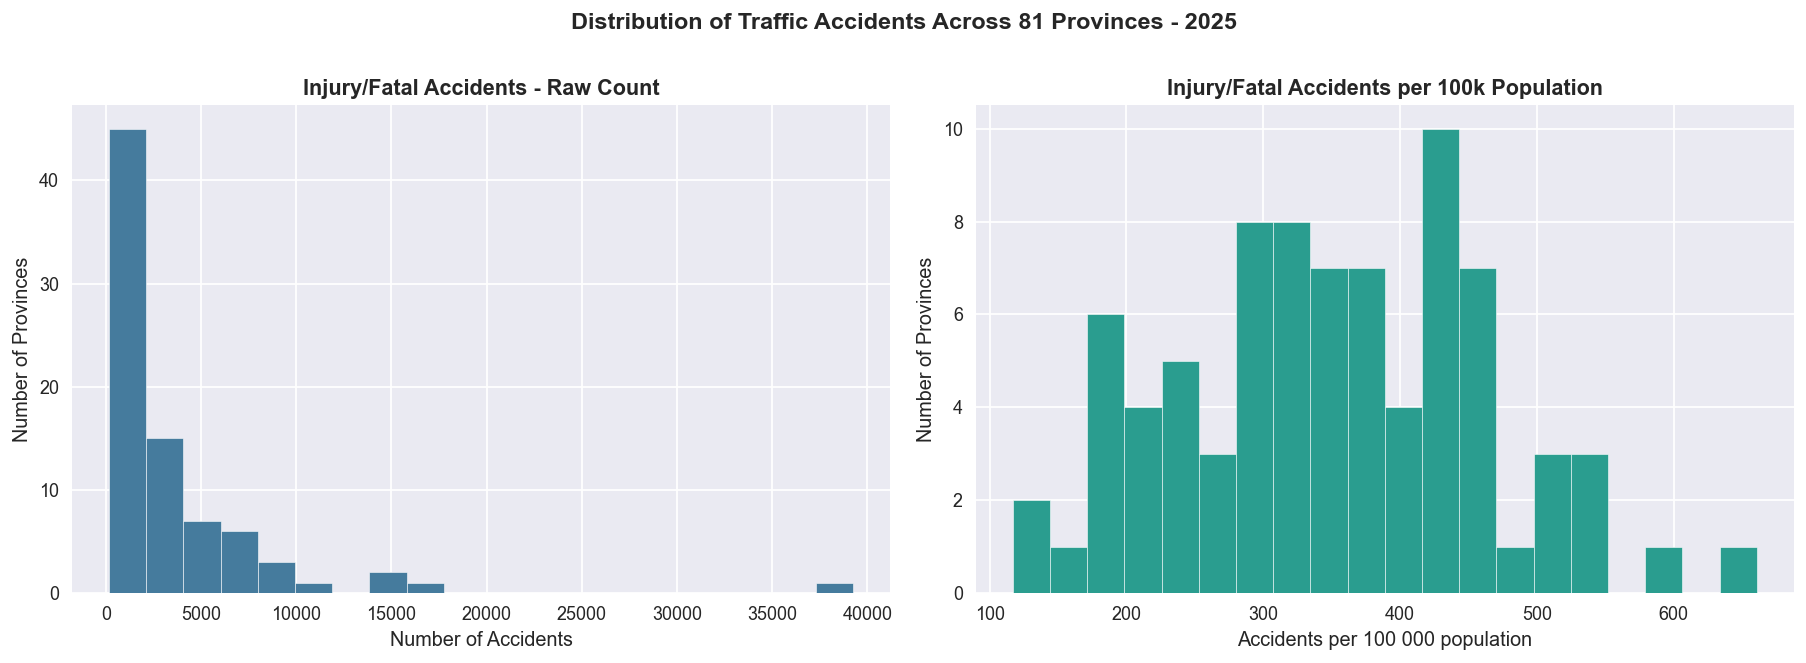

Skewness (raw)    : 4.47  | Skewness (per 100k): 0.14


In [44]:
# Histograms: raw counts vs normalised rates
#
# Left panel  -- raw counts: strongly right-skewed because Istanbul (39k)
#               and Ankara (18k) are extreme outliers vs rural provinces.
# Right panel -- per-100k rates: much less skewed once population is controlled,
#               making the variable more suitable for parametric tests.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['injury_fatal_accidents'], bins=20, color=BLUE, edgecolor='white')
axes[0].set_title('Injury/Fatal Accidents - Raw Count', fontweight='bold')
axes[0].set_xlabel('Number of Accidents')
axes[0].set_ylabel('Number of Provinces')

axes[1].hist(df['acc_per_100k'], bins=20, color=GREEN, edgecolor='white')
axes[1].set_title('Injury/Fatal Accidents per 100k Population', fontweight='bold')
axes[1].set_xlabel('Accidents per 100 000 population')
axes[1].set_ylabel('Number of Provinces')

plt.suptitle('Distribution of Traffic Accidents Across 81 Provinces - 2025',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig1_accident_distribution.png', bbox_inches='tight')
plt.show()

# Skewness: 0=symmetric, >0=right tail, <0=left tail
print('Skewness (raw)    :', round(df['injury_fatal_accidents'].skew(), 2),
      ' | Skewness (per 100k):', round(df['acc_per_100k'].skew(), 2))


### 3.3 Top and Bottom 10 Provinces by Accident Rate

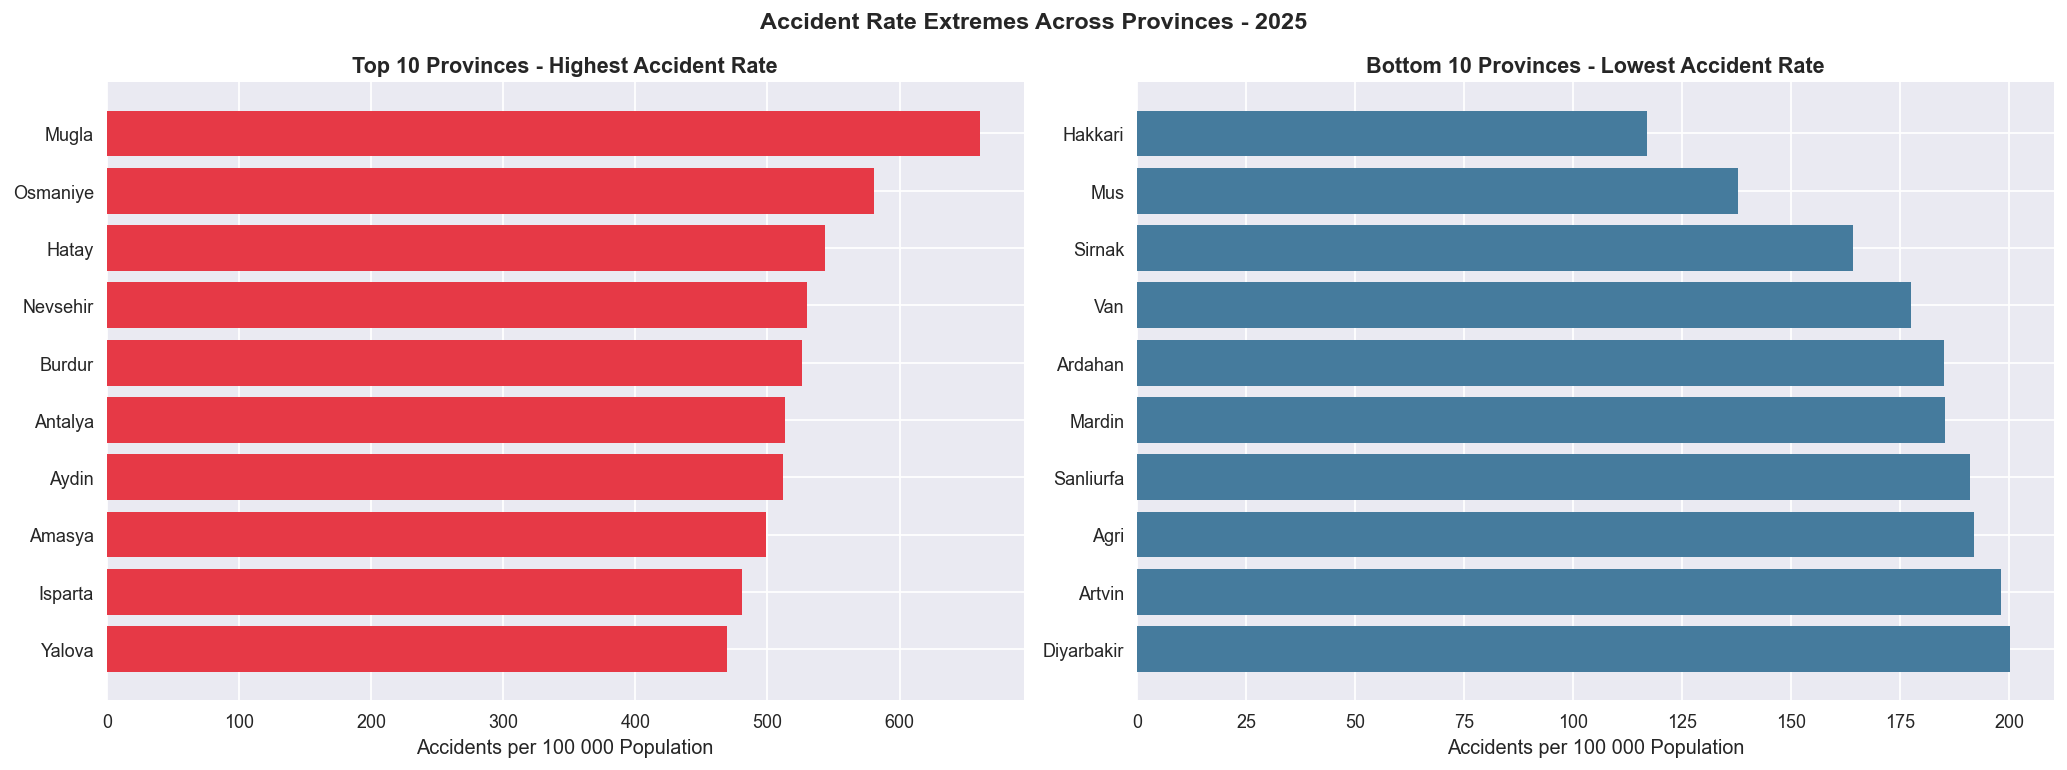

In [45]:
# Horizontal bar charts for extreme-ranking provinces
#
# Rankings are based on acc_per_100k (population-adjusted).
# Note: Mugla and coastal tourist provinces rank high partly because
# seasonal visitors inflate accident exposure without appearing in the
# resident population denominator -- a known data limitation.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top10 = df.nlargest(10, 'acc_per_100k')
bot10 = df.nsmallest(10, 'acc_per_100k')

axes[0].barh(top10['province'], top10['acc_per_100k'], color=ACCENT)
axes[0].set_title('Top 10 Provinces - Highest Accident Rate', fontweight='bold')
axes[0].set_xlabel('Accidents per 100 000 Population')
axes[0].invert_yaxis()   # highest value at the top

axes[1].barh(bot10['province'], bot10['acc_per_100k'], color=BLUE)
axes[1].set_title('Bottom 10 Provinces - Lowest Accident Rate', fontweight='bold')
axes[1].set_xlabel('Accidents per 100 000 Population')
axes[1].invert_yaxis()

plt.suptitle('Accident Rate Extremes Across Provinces - 2025', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_top_bottom10.png', bbox_inches='tight')
plt.show()


### 3.4 Big 3 Cities - Istanbul, Ankara, Izmir

Big 3 City Statistics - 2025


,injury_fatal_accidents,fatalities,injured,acc_per_100k,fatality_per_100k,injured_per_100k,population_2025,alcohol_rate_pct
province,,,,,,,,
Istanbul,39253,134,47861,245.0,0.8,298.8,16018524,17.2
Izmir,15509,122,19643,337.4,2.7,427.3,4597279,16.5
Ankara,17540,159,23717,298.0,2.7,402.9,5886877,12.6


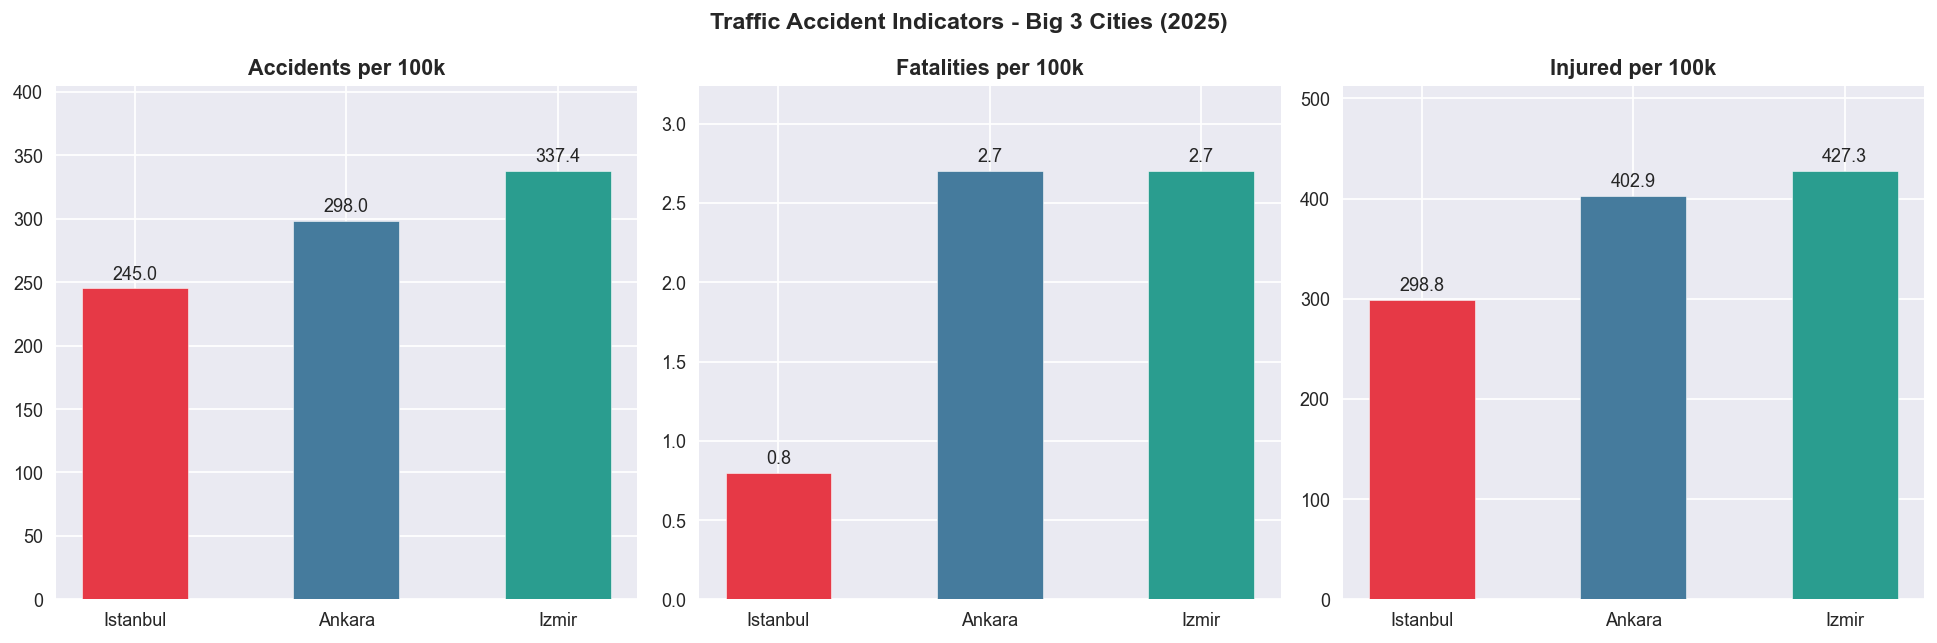

In [46]:
# Spotlight on Turkey's three largest cities
#
# Istanbul, Ankara, and Izmir account for ~38% of Turkey's population.
# Their absolute accident counts dominate national totals, but their
# per-100k rates are more moderate -- showing that count != risk per capita.

big3 = df[df['province'].isin(['Istanbul', 'Ankara', 'Izmir'])].copy()

metrics = ['injury_fatal_accidents','fatalities','injured',
           'acc_per_100k','fatality_per_100k','injured_per_100k']
print('Big 3 City Statistics - 2025')
display_full(big3.set_index('province')[metrics + ['population_2025','alcohol_rate_pct']].round(2))

# Bar chart comparison across the three cities
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
cities       = ['Istanbul', 'Ankara', 'Izmir']
colors       = [ACCENT, BLUE, GREEN]
metrics_plot = ['acc_per_100k', 'fatality_per_100k', 'injured_per_100k']
titles_plot  = ['Accidents per 100k', 'Fatalities per 100k', 'Injured per 100k']

for ax, metric, title in zip(axes, metrics_plot, titles_plot):
    vals = [big3.loc[big3['province'] == c, metric].values[0] for c in cities]
    bars = ax.bar(cities, vals, color=colors, width=0.5, edgecolor='white')
    ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=10)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.2)

plt.suptitle('Traffic Accident Indicators - Big 3 Cities (2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_big3_cities.png', bbox_inches='tight')
plt.show()


### 3.5 Accident Rate and Alcohol Consumption by IBBS1 Region

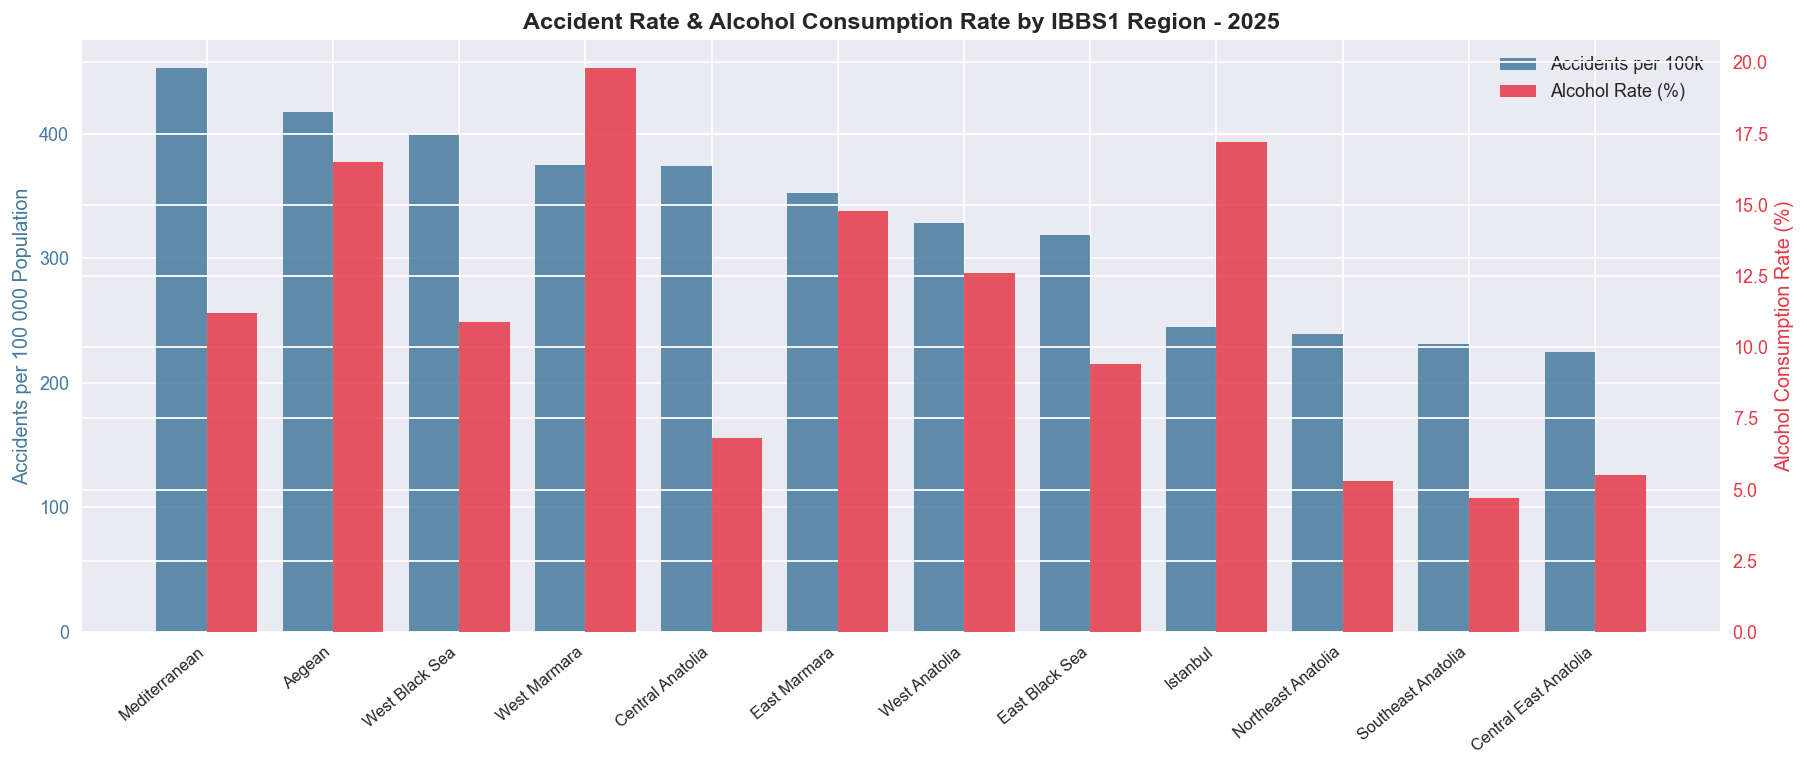

In [47]:
# Dual-axis bar chart: accident rate vs alcohol consumption by region
#
# Left axis (blue bars)  -- injury/fatal accidents per 100k population (2025)
# Right axis (red bars)  -- alcohol consumption rate % (TurkStat 2022)
#
# Sorting by accident rate (descending) makes the pattern easy to scan.
# Full region names shown on x-axis instead of short TR codes.

df_r = df_region.sort_values('acc_per_100k', ascending=False)

fig, ax1 = plt.subplots(figsize=(14, 6))
x     = np.arange(len(df_r))
width = 0.4

# Primary bars: accident rate
bars1 = ax1.bar(x - width / 2, df_r['acc_per_100k'], width,
                color=BLUE, label='Accidents per 100k', alpha=0.85)
ax1.set_ylabel('Accidents per 100 000 Population', color=BLUE, fontsize=11)
ax1.tick_params(axis='y', labelcolor=BLUE)
ax1.set_xticks(x)

# Strip the TR-code prefix (e.g. 'TR1 ') to get clean region names
region_labels = df_r['ibbs1_region'].str.replace(r'^TR[A-C0-9]+\s+', '', regex=True)
ax1.set_xticklabels(region_labels, rotation=40, ha='right', fontsize=9)
ax1.set_title('Accident Rate & Alcohol Consumption Rate by IBBS1 Region - 2025',
              fontsize=13, fontweight='bold')

# Secondary bars: alcohol rate on an independent right axis
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width / 2, df_r['alcohol_rate_pct'], width,
                color=ACCENT, label='Alcohol Rate (%)', alpha=0.85)
ax2.set_ylabel('Alcohol Consumption Rate (%)', color=ACCENT, fontsize=11)
ax2.tick_params(axis='y', labelcolor=ACCENT)

ax1.legend([bars1, bars2], ['Accidents per 100k', 'Alcohol Rate (%)'], loc='upper right')
plt.tight_layout()
plt.savefig('fig4_regional_comparison.png', bbox_inches='tight')
plt.show()


### 3.6 Scatter Plot - Alcohol Rate vs Accident Rate (Regional Level)

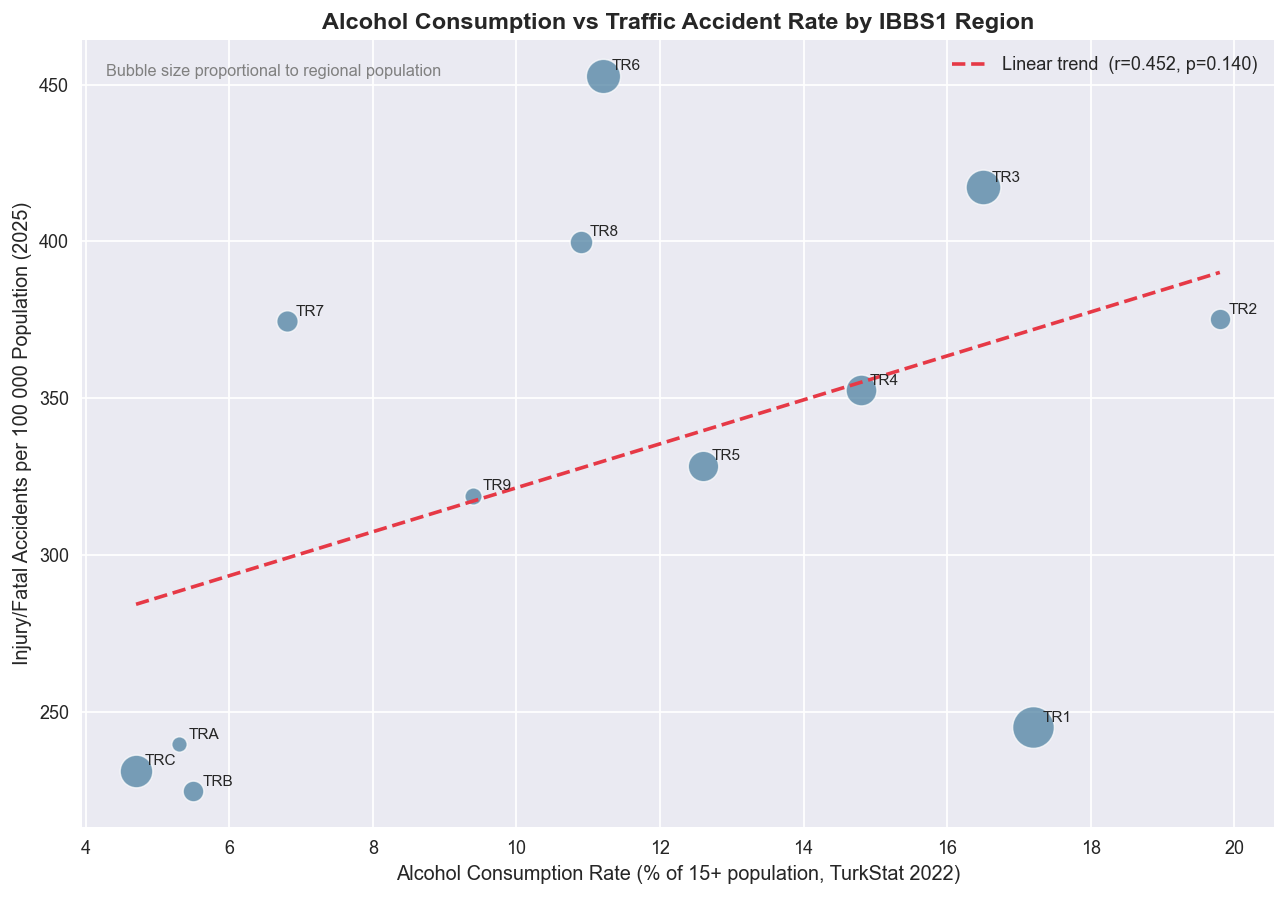

Pearson r = 0.4523, p = 0.1399  (descriptive trend line -- formal tests are in Section 4)


In [48]:
# Bubble scatter plot at regional level (n=12)
#
# Each bubble = one IBBS1 region.
# Bubble size   -> regional population (larger region = larger bubble)
# Dashed line   -> ordinary least-squares linear trend (descriptive only)
#
# This plot gives a visual first impression of the alcohol-accident
# relationship before formal tests are applied in Section 4.

fig, ax = plt.subplots(figsize=(10, 7))

for _, row in df_region.iterrows():
    ax.scatter(
        row['alcohol_rate_pct'],
        row['acc_per_100k'],
        s=row['total_population'] / 30_000,   # scale bubble to population
        alpha=0.7, color=BLUE, edgecolors='white', linewidth=0.8
    )
    ax.annotate(
        row['region_short'],
        xy=(row['alcohol_rate_pct'], row['acc_per_100k']),
        xytext=(5, 3), textcoords='offset points', fontsize=8.5
    )

# Fit a linear trend line (descriptive -- not a hypothesis test)
m, b, r, p_lr, _ = stats.linregress(
    df_region['alcohol_rate_pct'], df_region['acc_per_100k']
)
x_line = np.linspace(df_region['alcohol_rate_pct'].min(),
                     df_region['alcohol_rate_pct'].max(), 100)
ax.plot(x_line, m * x_line + b, '--', color=ACCENT, linewidth=2,
        label=f'Linear trend  (r={r:.3f}, p={p_lr:.3f})')

ax.set_xlabel('Alcohol Consumption Rate (% of 15+ population, TurkStat 2022)', fontsize=11)
ax.set_ylabel('Injury/Fatal Accidents per 100 000 Population (2025)', fontsize=11)
ax.set_title('Alcohol Consumption vs Traffic Accident Rate by IBBS1 Region',
             fontsize=13, fontweight='bold')
ax.annotate('Bubble size proportional to regional population',
            xy=(0.02, 0.97), xycoords='axes fraction', fontsize=9, color='gray', va='top')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig5_scatter_alcohol_vs_accidents.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'Pearson r = {r:.4f}, p = {p_lr:.4f}  '
      f'(descriptive trend line -- formal tests are in Section 4)')


### 3.7 Correlation Heatmap - Regional Variables

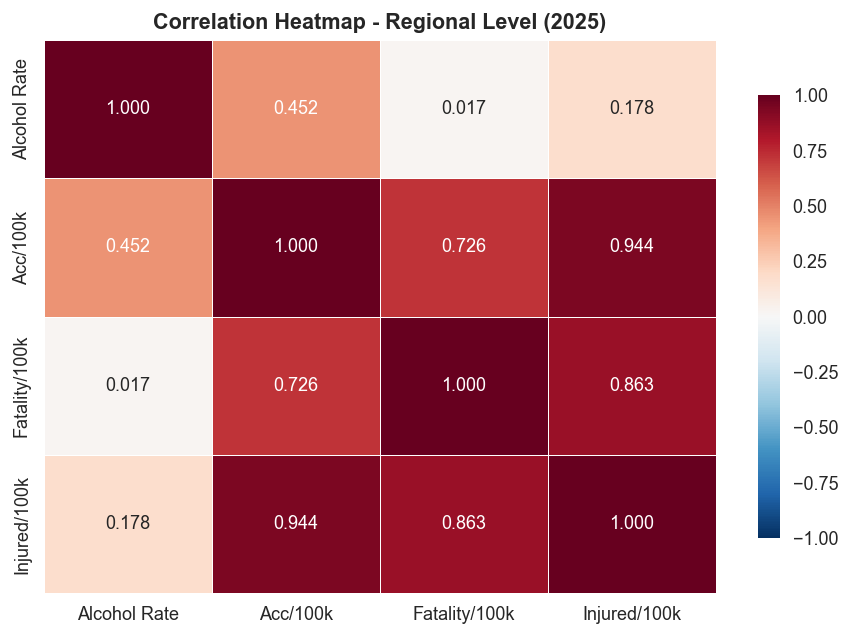

In [49]:
# Pairwise correlation heatmap for regional-level numeric variables
#
# Pearson correlation coefficients are shown for the four key variables.
# Values range from -1 (perfect negative) to +1 (perfect positive).
# Red = positive, Blue = negative.
#
# This heatmap shows which variables move together but does not constitute
# a significance test -- that is handled in Section 4.

corr_cols   = ['alcohol_rate_pct', 'acc_per_100k', 'fatality_per_100k', 'injured_per_100k']
corr_labels = ['Alcohol Rate', 'Acc/100k', 'Fatality/100k', 'Injured/100k']

# Compute pairwise Pearson correlation matrix
corr_matrix = df_region[corr_cols].corr()
corr_matrix.index   = corr_labels
corr_matrix.columns = corr_labels

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.3f',
    cmap='RdBu_r',   # Red-Blue diverging palette centred at 0
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Heatmap - Regional Level (2025)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_correlation_heatmap.png', bbox_inches='tight')
plt.show()


### 3.8 Year-Over-Year Comparison - 2025 vs Projected 2026

Provinces by projected change 2025 -> 2026 (Q1 x 4):


,province,injury_fatal_accidents_2025,projected_2026,change_pct
0,Istanbul,39253,34932,-11.0
1,Bartin,657,572,-12.9
2,Sirnak,988,856,-13.4
3,Kocaeli,7823,6676,-14.7
4,Adana,6765,5760,-14.9
5,Ankara,17540,14824,-15.5
6,Zonguldak,1884,1588,-15.7
7,Trabzon,2539,2132,-16.0
8,Bursa,10290,8592,-16.5
9,Rize,1151,948,-17.6


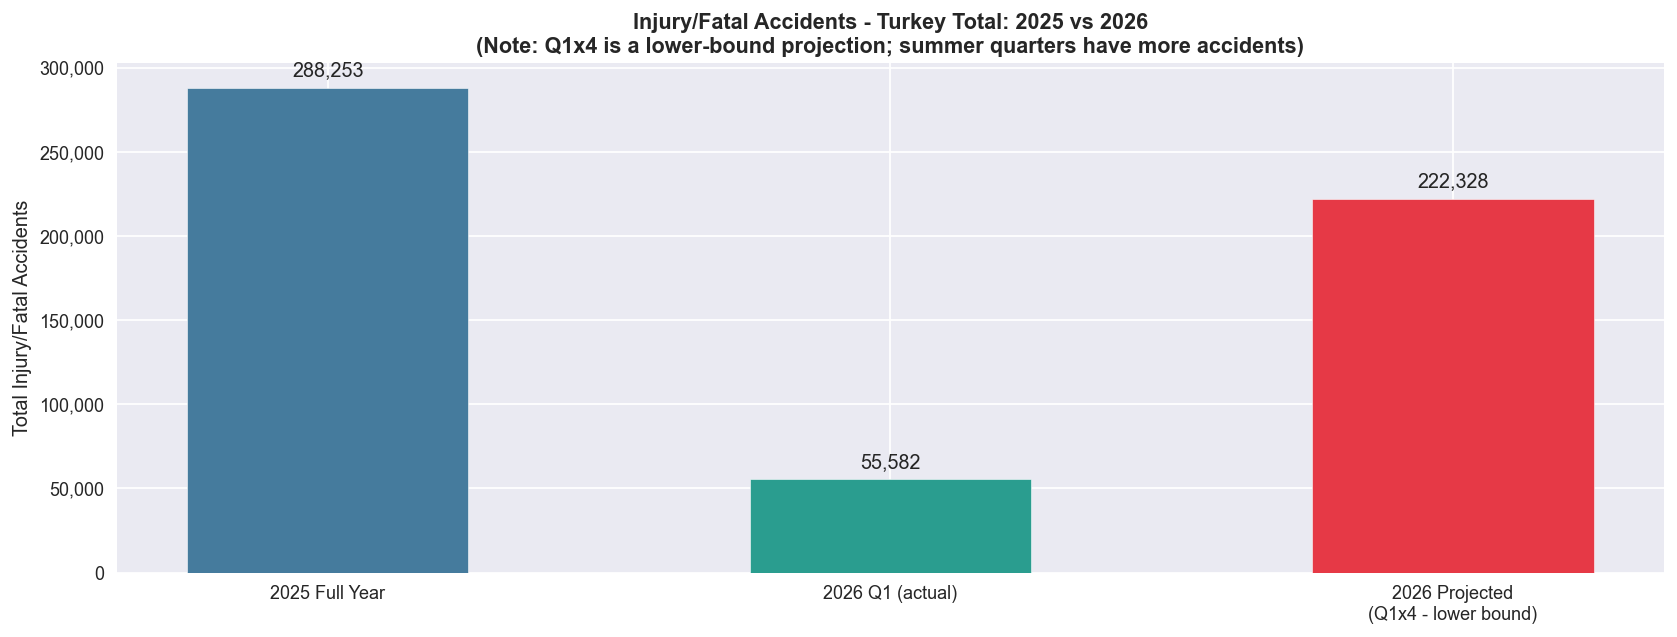

In [50]:
# Year-over-year accident trend analysis
#
# 2026 annual total is projected as Q1 (Jan-Mar) counts x 4.
# This is a conservative lower-bound estimate because:
#   (a) Q1 is Turkey's lowest-traffic quarter (winter, less tourism)
#   (b) Peak accident months (July-August) have not yet occurred in Q1
#
# The projection is used for descriptive comparison here.
# A formal statistical test (H5 - Wilcoxon) is applied in Section 4.

# Build a province-level comparison table: 2025 actuals vs Q1-derived projection
df_yoy = df_2025[['province', 'injury_fatal_accidents', 'fatalities']].copy()
df_yoy = df_yoy.merge(
    df_2026q1[['province', 'injury_fatal_accidents', 'fatalities']],
    on='province', suffixes=('_2025', '_2026q1')
)

df_yoy['projected_2026'] = df_yoy['injury_fatal_accidents_2026q1'] * 4

# Percentage change from 2025 actual to 2026 projection
df_yoy['change_pct'] = (
    (df_yoy['projected_2026'] - df_yoy['injury_fatal_accidents_2025'])
    / df_yoy['injury_fatal_accidents_2025'] * 100
)

print('Provinces by projected change 2025 -> 2026 (Q1 x 4):')
display_full(
    df_yoy[['province', 'injury_fatal_accidents_2025', 'projected_2026', 'change_pct']]
    .sort_values('change_pct', ascending=False)
    .round(1).reset_index(drop=True)
)

# National total bar chart
fig, ax = plt.subplots(figsize=(13, 5))
totals = {
    '2025 Full Year'                       : df_2025['injury_fatal_accidents'].sum(),
    '2026 Q1 (actual)'                     : df_2026q1['injury_fatal_accidents'].sum(),
    '2026 Projected\n(Q1x4 - lower bound)' : df_2026q1['injury_fatal_accidents'].sum() * 4
}
bars = ax.bar(totals.keys(), totals.values(), color=[BLUE, GREEN, ACCENT],
              width=0.5, edgecolor='white')
ax.bar_label(bars, fmt='{:,.0f}', padding=4, fontsize=11)
ax.set_title('Injury/Fatal Accidents - Turkey Total: 2025 vs 2026\n'
             '(Note: Q1x4 is a lower-bound projection; summer quarters have more accidents)',
             fontweight='bold')
ax.set_ylabel('Total Injury/Fatal Accidents')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('fig7_year_comparison.png', bbox_inches='tight')
plt.show()


## 4. Hypothesis Testing

Six statistical tests examine whether alcohol consumption is associated with
higher traffic-accident rates in Turkey.

| # | Test | Level | n | Question |
|---|------|-------|---|----------|
| **H1** | Independent Samples T-test | Province | 81 | Do high-alcohol provinces have a higher **mean** accident rate? |
| **H2** | One-Way ANOVA | Province | 81 | Do accident rates differ across **3 alcohol tiers**? |
| **H3** | Mann-Whitney U Test | Regional | 12 | Do high-alcohol **regions** have higher accident rates? |
| **H4** | Kruskal-Wallis Test | Province | 81 | Non-parametric: do **distributions** differ across 3 tiers? |
| **H5** | Wilcoxon Signed-Rank Test | Province | 81 pairs | Did rates **change** from 2025 to projected 2026? |
| **H6** | Chi-Square Test | Province | 81 | Are alcohol category and accident category **associated**? |

**Significance level: alpha = 0.05 for all tests.**

> **Why no Z-test?** The Z-test requires the true population variance to be known.
> Because we only have sample data, the variance must be estimated -- which makes
> the statistic a t-statistic, not a z-statistic. The Z-test therefore offers no
> advantage over the T-test here and is omitted.


### 4.1 Hypothesis 1 - Independent Samples T-test
**Question:** Do provinces in high-alcohol regions have a significantly higher
**mean** accident rate than provinces in low-alcohol regions?

Welch's version is used because it does not assume equal variances between
groups, making it more robust than Student's t-test.


Hypothesis 1: Independent Samples T-test (Welch's)
-----------------------------------------------------------------
H0: mu(high-alcohol provinces) = mu(low-alcohol provinces)
H1: mu(high-alcohol provinces) > mu(low-alcohol provinces)

Median alcohol rate used for split: 10.9%
  HIGH group : n=43, mean=408.1, SD=86.5
  LOW  group : n=38,  mean=284.3, SD=97.1

Test statistic  t = 6.0260
p-value (one-tailed) = 0.0000
Significance level alpha = 0.05

Decision: REJECT H0 at alpha = 0.05
Conclusion: High-alcohol provinces have a significantly higher mean
            accident rate than low-alcohol provinces.


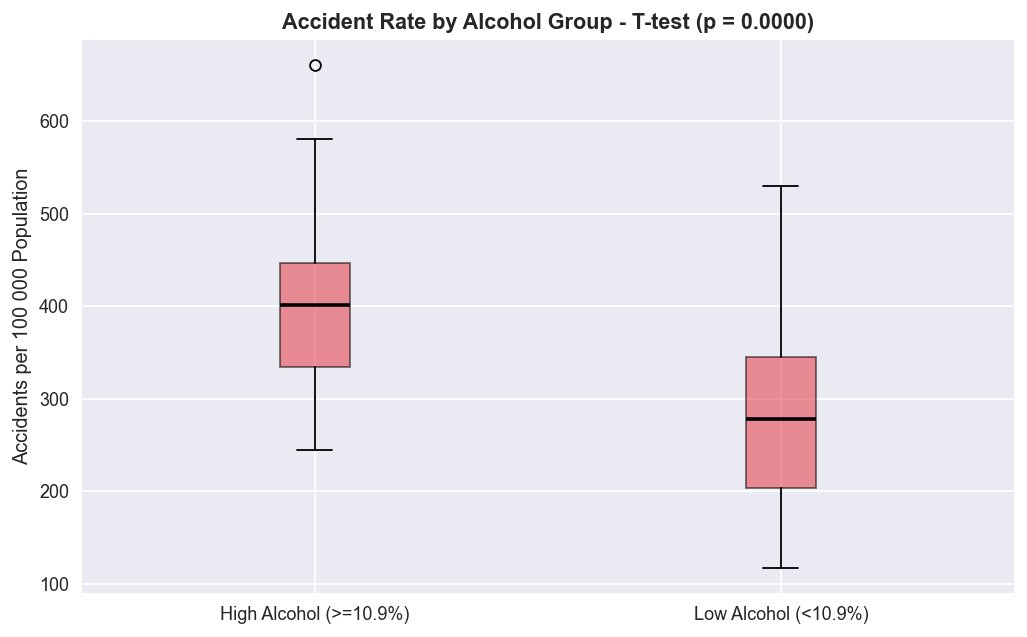

In [51]:
# Global significance level used for all six tests
alpha = 0.05

# Group provinces into high vs low alcohol using the median alcohol rate
# Each of the 81 provinces inherits the alcohol rate of its IBBS1 region.
# We split at the median so both groups are roughly equal in size.
median_alc_prov = df['alcohol_rate_pct'].median()

high_prov = df[df['alcohol_rate_pct'] >= median_alc_prov]['acc_per_100k']
low_prov  = df[df['alcohol_rate_pct'] <  median_alc_prov]['acc_per_100k']

# Welch's independent-samples t-test
# equal_var=False -> Welch's (does not assume equal group variances)
# alternative='greater' -> one-tailed test: H1 states high-alcohol > low-alcohol
t_stat, p_ttest = stats.ttest_ind(high_prov, low_prov,
                                   equal_var=False, alternative='greater')

print('=' * 65)
print('Hypothesis 1: Independent Samples T-test (Welch\'s)')
print('-' * 65)
print('H0: mu(high-alcohol provinces) = mu(low-alcohol provinces)')
print('H1: mu(high-alcohol provinces) > mu(low-alcohol provinces)')
print(f'\nMedian alcohol rate used for split: {median_alc_prov:.1f}%')
print(f'  HIGH group : n={len(high_prov):2d}, mean={high_prov.mean():.1f}, SD={high_prov.std():.1f}')
print(f'  LOW  group : n={len(low_prov):2d},  mean={low_prov.mean():.1f}, SD={low_prov.std():.1f}')
print(f'\nTest statistic  t = {t_stat:.4f}')
print(f'p-value (one-tailed) = {p_ttest:.4f}')
print(f'Significance level alpha = {alpha}')
if p_ttest < alpha:
    print(f'\nDecision: REJECT H0 at alpha = {alpha}')
    print('Conclusion: High-alcohol provinces have a significantly higher mean')
    print('            accident rate than low-alcohol provinces.')
else:
    print(f'\nDecision: FAIL TO REJECT H0 at alpha = {alpha}')
    print('Conclusion: No significant difference in mean accident rates.')
print('=' * 65)

# Box plot comparing the two groups
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(
    [high_prov.values, low_prov.values],
    labels=[f'High Alcohol (>={median_alc_prov:.1f}%)', f'Low Alcohol (<{median_alc_prov:.1f}%)'],
    patch_artist=True,
    boxprops=dict(facecolor=ACCENT, alpha=0.55),
    medianprops=dict(color='black', linewidth=2)
)
ax.set_ylabel('Accidents per 100 000 Population', fontsize=11)
ax.set_title(f'Accident Rate by Alcohol Group - T-test (p = {p_ttest:.4f})', fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_ttest_boxplot.png', bbox_inches='tight')
plt.show()


### 4.2 Hypothesis 2 - One-Way ANOVA
**Question:** Do mean accident rates differ significantly across three
alcohol consumption tiers?

**Tier boundaries** (based on natural breaks in the alcohol rate distribution):
- **Low** (<8%): TR7, TRA, TRB, TRC -- predominantly eastern regions
- **Mid** (8-14%): TR8, TR9, TR6, TR5 -- central and coastal regions
- **High** (>14%): TR4, TR1, TR3, TR2 -- western, urbanised regions

**Pre-condition:** Levene's test for equality of variances is run first.


Group descriptive statistics:
  Low (<8%)        n=32  mean=281.6  SD=102.9
  Mid (8-14%)      n=27  mean=397.8  SD=94.4
  High (>14%)      n=22  mean=390.9  SD=88.4

Levene's test for equal variances: F = 0.8529, p = 0.4301
  -> Equal variances assumed (p > 0.05): standard ANOVA is valid.

Hypothesis 2: One-Way ANOVA
-----------------------------------------------------------------
H0: mu_low = mu_mid = mu_high  (all group means are equal)
H1: At least one group mean is different

Test statistic  F = 13.3695
p-value             = 0.0000
Significance level alpha = 0.05

Decision: REJECT H0 at alpha = 0.05
Conclusion: At least one alcohol tier has a significantly different mean accident rate.


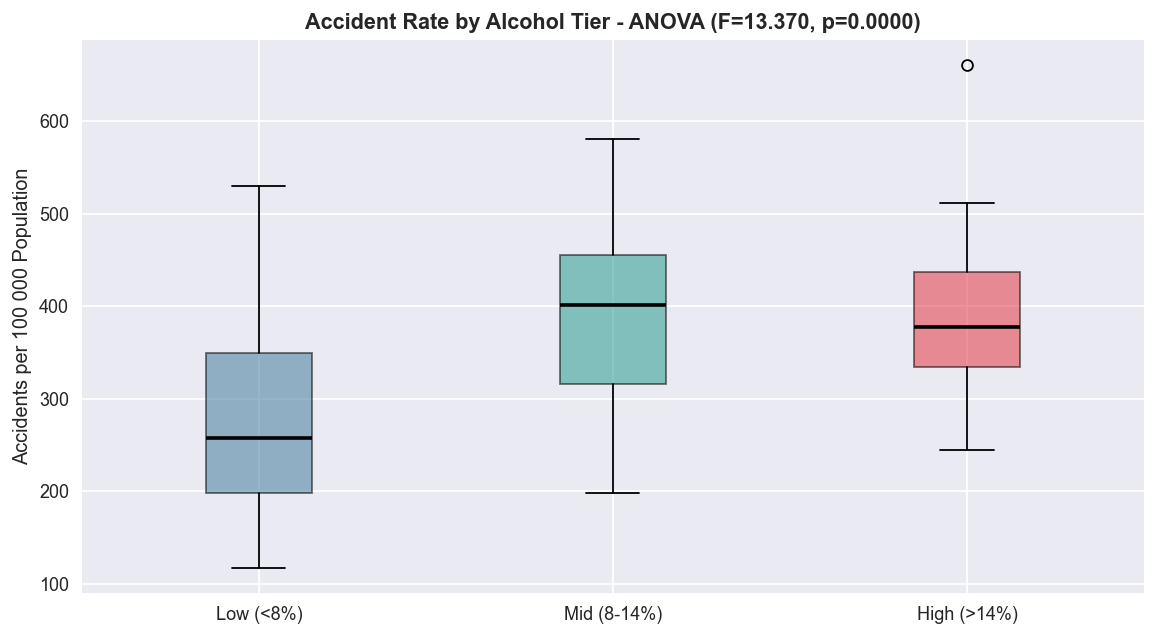

In [52]:
# Assign each province to one of three alcohol tiers
# Boundaries set at 8% and 14% to align with natural breaks in the data.

def assign_tier(rate):
    """Return alcohol tier label based on the regional consumption rate."""
    if rate < 8:
        return 'Low (<8%)'
    elif rate <= 14:
        return 'Mid (8-14%)'
    else:
        return 'High (>14%)'

df['alcohol_tier'] = df['alcohol_rate_pct'].apply(assign_tier)

# Extract acc_per_100k values for each tier
low_tier  = df[df['alcohol_tier'] == 'Low (<8%)' ]['acc_per_100k']
mid_tier  = df[df['alcohol_tier'] == 'Mid (8-14%)']['acc_per_100k']
high_tier = df[df['alcohol_tier'] == 'High (>14%)']['acc_per_100k']

print('Group descriptive statistics:')
for name, grp in [('Low (<8%)', low_tier), ('Mid (8-14%)', mid_tier), ('High (>14%)', high_tier)]:
    print(f'  {name:15s}  n={len(grp):2d}  mean={grp.mean():.1f}  SD={grp.std():.1f}')

# Levene's test for homogeneity of variances
# H0: all group variances are equal
# p > alpha -> equal variances assumed -> standard ANOVA valid
# p <= alpha -> unequal variances -> prefer Kruskal-Wallis (H4)
lev_stat, p_levene = stats.levene(low_tier, mid_tier, high_tier)
print(f'\nLevene\'s test for equal variances: F = {lev_stat:.4f}, p = {p_levene:.4f}')
if p_levene > alpha:
    print('  -> Equal variances assumed (p > 0.05): standard ANOVA is valid.')
else:
    print('  -> Unequal variances (p <= 0.05): interpret ANOVA with caution.')
    print('     Kruskal-Wallis (H4) should be preferred in this case.')

# One-Way ANOVA
# F = variance between groups / variance within groups
f_stat, p_anova = stats.f_oneway(low_tier, mid_tier, high_tier)

print('\n' + '=' * 65)
print('Hypothesis 2: One-Way ANOVA')
print('-' * 65)
print('H0: mu_low = mu_mid = mu_high  (all group means are equal)')
print('H1: At least one group mean is different')
print(f'\nTest statistic  F = {f_stat:.4f}')
print(f'p-value             = {p_anova:.4f}')
print(f'Significance level alpha = {alpha}')
if p_anova < alpha:
    print(f'\nDecision: REJECT H0 at alpha = {alpha}')
    print('Conclusion: At least one alcohol tier has a significantly different mean accident rate.')
else:
    print(f'\nDecision: FAIL TO REJECT H0 at alpha = {alpha}')
    print('Conclusion: No significant difference in mean accident rates across tiers.')
print('=' * 65)

# Box plot by tier
fig, ax = plt.subplots(figsize=(9, 5))
tier_labels = ['Low (<8%)', 'Mid (8-14%)', 'High (>14%)']
tier_colors = [BLUE, GREEN, ACCENT]
bp = ax.boxplot([low_tier.values, mid_tier.values, high_tier.values],
               labels=tier_labels, patch_artist=True,
               medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], tier_colors):
    patch.set_facecolor(color); patch.set_alpha(0.55)
ax.set_ylabel('Accidents per 100 000 Population', fontsize=11)
ax.set_title(f'Accident Rate by Alcohol Tier - ANOVA (F={f_stat:.3f}, p={p_anova:.4f})',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_anova_boxplot.png', bbox_inches='tight')
plt.show()


### 4.3 Hypothesis 3 - Mann-Whitney U Test
**Question:** Do regions with above-median alcohol consumption have significantly
higher accident rates than regions below the median?

*Applied at regional level (n=12) because alcohol data is only available at
IBBS1 granularity. Non-parametric -- no normality assumption needed.*


Hypothesis 3: Mann-Whitney U Test
-----------------------------------------------------------------
H0: Accident rate distributions are equal in high- and low-alcohol regions
H1: High-alcohol regions have higher accident rates (one-tailed)

Median alcohol rate (regional level): 11.1%
  HIGH regions: ['TR1', 'TR2', 'TR3', 'TR4', 'TR5', 'TR6']
  LOW  regions: ['TR7', 'TR8', 'TR9', 'TRA', 'TRB', 'TRC']

  HIGH: mean=361.9, median=363.8
  LOW : mean=298.1, median=279.2

Test statistic  U = 28.0
p-value (one-tailed) = 0.0660
Significance level alpha = 0.05

Decision: FAIL TO REJECT H0 at alpha = 0.05
Conclusion: No significant difference between groups.

Effect size (rank-biserial r) = -0.556
  -> Large effect


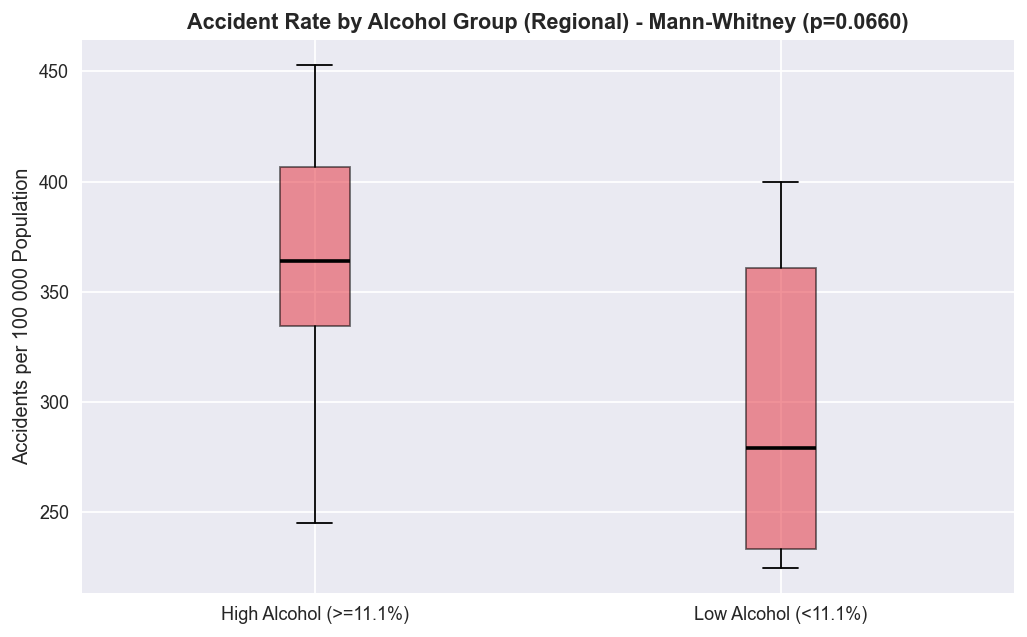

In [53]:
# Split 12 regions into high vs low alcohol groups at the regional median
median_alc_reg = df_region['alcohol_rate_pct'].median()

high_reg = df_region[df_region['alcohol_rate_pct'] >= median_alc_reg]['acc_per_100k']
low_reg  = df_region[df_region['alcohol_rate_pct'] <  median_alc_reg]['acc_per_100k']

# Mann-Whitney U test: one-tailed (H1: high > low)
# Ranks all observations together and checks if one group's ranks are higher
u_stat, p_mw = stats.mannwhitneyu(high_reg, low_reg, alternative='greater')

print('=' * 65)
print('Hypothesis 3: Mann-Whitney U Test')
print('-' * 65)
print('H0: Accident rate distributions are equal in high- and low-alcohol regions')
print('H1: High-alcohol regions have higher accident rates (one-tailed)')
print(f'\nMedian alcohol rate (regional level): {median_alc_reg:.1f}%')
print(f'  HIGH regions: {list(df_region[df_region["alcohol_rate_pct"] >= median_alc_reg]["region_short"])}')
print(f'  LOW  regions: {list(df_region[df_region["alcohol_rate_pct"] <  median_alc_reg]["region_short"])}')
print(f'\n  HIGH: mean={high_reg.mean():.1f}, median={high_reg.median():.1f}')
print(f'  LOW : mean={low_reg.mean():.1f}, median={low_reg.median():.1f}')
print(f'\nTest statistic  U = {u_stat:.1f}')
print(f'p-value (one-tailed) = {p_mw:.4f}')
print(f'Significance level alpha = {alpha}')
if p_mw < alpha:
    print(f'\nDecision: REJECT H0 at alpha = {alpha}')
    print('Conclusion: High-alcohol regions have significantly higher accident rates.')
else:
    print(f'\nDecision: FAIL TO REJECT H0 at alpha = {alpha}')
    print('Conclusion: No significant difference between groups.')

# Effect size: rank-biserial correlation
# Ranges from -1 to +1. |r| < 0.3 = small, 0.3-0.5 = medium, > 0.5 = large
n1, n2 = len(high_reg), len(low_reg)
rank_biserial = 1 - (2 * u_stat) / (n1 * n2)
print(f'\nEffect size (rank-biserial r) = {rank_biserial:.3f}')
print('  ->', 'Large' if abs(rank_biserial) >= 0.5 else ('Medium' if abs(rank_biserial) >= 0.3 else 'Small'), 'effect')
print('=' * 65)

# Box plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(
    [high_reg.values, low_reg.values],
    labels=[f'High Alcohol (>={median_alc_reg:.1f}%)', f'Low Alcohol (<{median_alc_reg:.1f}%)'],
    patch_artist=True,
    boxprops=dict(facecolor=ACCENT, alpha=0.55),
    medianprops=dict(color='black', linewidth=2)
)
ax.set_ylabel('Accidents per 100 000 Population', fontsize=11)
ax.set_title(f'Accident Rate by Alcohol Group (Regional) - Mann-Whitney (p={p_mw:.4f})',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_mannwhitney_boxplot.png', bbox_inches='tight')
plt.show()


### 4.4 Hypothesis 4 - Kruskal-Wallis Test
**Question:** Do accident rate distributions differ significantly across
the three alcohol tiers?

*Non-parametric equivalent of One-Way ANOVA. Does not require normality
or equal variances.*


Hypothesis 4: Kruskal-Wallis Test
-----------------------------------------------------------------
H0: Accident rate distributions are equal across all 3 alcohol tiers
H1: At least one tier has a different distribution

Group sizes -> Low: n=32, Mid: n=27, High: n=22

Test statistic  H = 19.4415
p-value             = 0.0001
Significance level alpha = 0.05

Decision: REJECT H0 at alpha = 0.05
Conclusion: At least one alcohol tier shows a significantly different
            accident rate distribution.


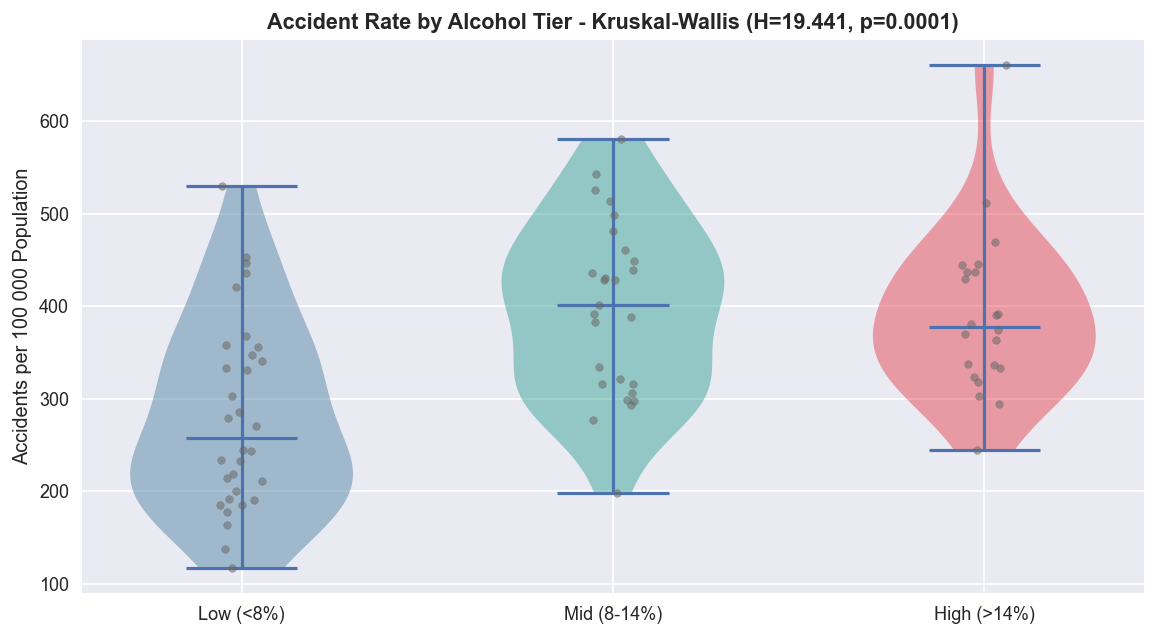

In [54]:
# Kruskal-Wallis test across the same 3 tiers as ANOVA (H2)
#
# The test ranks all 81 province values together, then checks whether
# average ranks differ significantly across the three groups.
# The H statistic follows a chi-square distribution with (k-1) = 2 df.

kw_stat, p_kw = stats.kruskal(low_tier, mid_tier, high_tier)

print('=' * 65)
print('Hypothesis 4: Kruskal-Wallis Test')
print('-' * 65)
print('H0: Accident rate distributions are equal across all 3 alcohol tiers')
print('H1: At least one tier has a different distribution')
print(f'\nGroup sizes -> Low: n={len(low_tier)}, Mid: n={len(mid_tier)}, High: n={len(high_tier)}')
print(f'\nTest statistic  H = {kw_stat:.4f}')
print(f'p-value             = {p_kw:.4f}')
print(f'Significance level alpha = {alpha}')
if p_kw < alpha:
    print(f'\nDecision: REJECT H0 at alpha = {alpha}')
    print('Conclusion: At least one alcohol tier shows a significantly different')
    print('            accident rate distribution.')
else:
    print(f'\nDecision: FAIL TO REJECT H0 at alpha = {alpha}')
    print('Conclusion: No significant difference in distributions across tiers.')
print('=' * 65)

# Violin + strip plot
# Violin: full distribution shape; strips: individual province data points
fig, ax = plt.subplots(figsize=(9, 5))
tier_data = [low_tier.values, mid_tier.values, high_tier.values]
parts = ax.violinplot(tier_data, positions=[1, 2, 3], showmedians=True, widths=0.6)
for pc, color in zip(parts['bodies'], [BLUE, GREEN, ACCENT]):
    pc.set_facecolor(color); pc.set_alpha(0.45)
np.random.seed(42)   # fix jitter for reproducibility
for data, pos in zip(tier_data, [1, 2, 3]):
    jitter = np.random.uniform(-0.06, 0.06, len(data))
    ax.scatter(np.full_like(data, pos) + jitter, data,
               alpha=0.55, s=18, zorder=3, color='dimgray')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Low (<8%)', 'Mid (8-14%)', 'High (>14%)'])
ax.set_ylabel('Accidents per 100 000 Population', fontsize=11)
ax.set_title(f'Accident Rate by Alcohol Tier - Kruskal-Wallis (H={kw_stat:.3f}, p={p_kw:.4f})',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig11_kruskalwallis_violin.png', bbox_inches='tight')
plt.show()


### 4.5 Hypothesis 5 - Wilcoxon Signed-Rank Test
**Question:** Did accident rates change significantly between 2025 and
the projected 2026 annual total?

*Paired non-parametric test. Each of the 81 provinces contributes one
2025 rate and one projected 2026 rate -- the pairing controls for
province-specific characteristics.*


Hypothesis 5: Wilcoxon Signed-Rank Test
-----------------------------------------------------------------
H0: Median(acc_per_100k_2026_proj - acc_per_100k_2025) = 0
H1: Median difference != 0  (two-tailed)

n = 81 matched province pairs
Median 2025 acc/100k          : 340.7
Median 2026 projected acc/100k: 258.8
Median paired difference      : -96.3

Test statistic  W = 0.0
p-value (two-tailed) = 0.0000
Significance level alpha = 0.05

Decision: REJECT H0 at alpha = 0.05
Conclusion: A statistically significant decrease in accident rates
            is observed from 2025 to projected 2026.


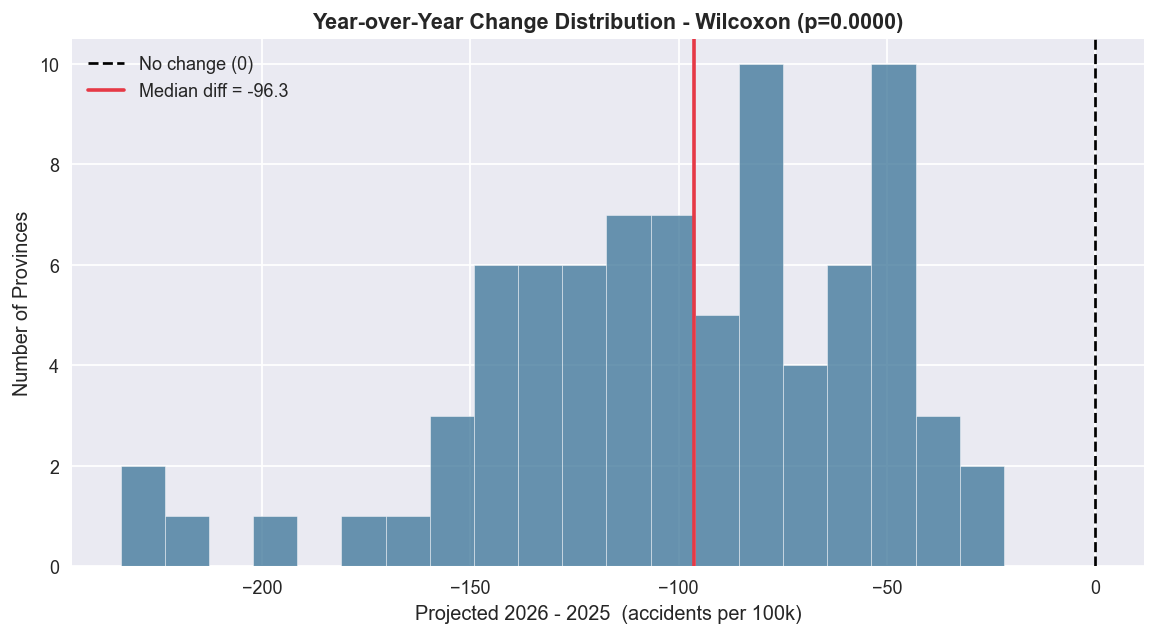

In [55]:
# Build paired province-level per-100k rates for both years
# Join df_2025, df_2026q1, and df_pop by province to get raw counts
# and population, then compute normalised rate for each year.

df_wilcox = (
    df_2025[['province', 'injury_fatal_accidents']]
    .merge(df_pop, on='province')
    .merge(
        df_2026q1[['province', 'injury_fatal_accidents']],
        on='province', suffixes=('_2025', '_2026q1')
    )
)

# Per-100k rate for 2025
df_wilcox['acc_per_100k_2025'] = (
    df_wilcox['injury_fatal_accidents_2025'] / df_wilcox['population_2025'] * 100_000
)

# Per-100k rate for projected 2026 (Q1 x 4 -- conservative lower bound)
df_wilcox['acc_per_100k_2026_proj'] = (
    df_wilcox['injury_fatal_accidents_2026q1'] * 4 / df_wilcox['population_2025'] * 100_000
)

# Wilcoxon signed-rank test (two-tailed: test for any change, not directional)
w_stat, p_wilcox = stats.wilcoxon(
    df_wilcox['acc_per_100k_2026_proj'],
    df_wilcox['acc_per_100k_2025'],
    alternative='two-sided'
)

# Median of paired differences
# Positive -> rates increased from 2025 to projected 2026
# Negative -> rates decreased
median_diff = (df_wilcox['acc_per_100k_2026_proj'] - df_wilcox['acc_per_100k_2025']).median()

print('=' * 65)
print('Hypothesis 5: Wilcoxon Signed-Rank Test')
print('-' * 65)
print('H0: Median(acc_per_100k_2026_proj - acc_per_100k_2025) = 0')
print('H1: Median difference != 0  (two-tailed)')
print(f'\nn = {len(df_wilcox)} matched province pairs')
print(f'Median 2025 acc/100k          : {df_wilcox["acc_per_100k_2025"].median():.1f}')
print(f'Median 2026 projected acc/100k: {df_wilcox["acc_per_100k_2026_proj"].median():.1f}')
print(f'Median paired difference      : {median_diff:+.1f}')
print(f'\nTest statistic  W = {w_stat:.1f}')
print(f'p-value (two-tailed) = {p_wilcox:.4f}')
print(f'Significance level alpha = {alpha}')
if p_wilcox < alpha:
    direction = 'increase' if median_diff > 0 else 'decrease'
    print(f'\nDecision: REJECT H0 at alpha = {alpha}')
    print(f'Conclusion: A statistically significant {direction} in accident rates')
    print('            is observed from 2025 to projected 2026.')
else:
    print(f'\nDecision: FAIL TO REJECT H0 at alpha = {alpha}')
    print('Conclusion: No significant change in accident rates between years.')
print('=' * 65)

# Histogram of paired differences
# Bars left of 0 = provinces where rate dropped; right = where rate increased
fig, ax = plt.subplots(figsize=(9, 5))
diffs = df_wilcox['acc_per_100k_2026_proj'] - df_wilcox['acc_per_100k_2025']
ax.hist(diffs, bins=20, color=BLUE, edgecolor='white', alpha=0.8)
ax.axvline(0,           color='black', linestyle='--', linewidth=1.5, label='No change (0)')
ax.axvline(median_diff, color=ACCENT,  linestyle='-',  linewidth=2,
           label=f'Median diff = {median_diff:+.1f}')
ax.set_xlabel('Projected 2026 - 2025  (accidents per 100k)', fontsize=11)
ax.set_ylabel('Number of Provinces', fontsize=11)
ax.set_title(f'Year-over-Year Change Distribution - Wilcoxon (p={p_wilcox:.4f})',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig12_wilcoxon_diff_hist.png', bbox_inches='tight')
plt.show()


### 4.6 Hypothesis 6 - Chi-Square Test of Independence
**Question:** Is alcohol category (high/low) associated with accident rate
category (high/low) at province level?

**Validity check:** All expected cell frequencies must be >= 5 for the
chi-square approximation to hold. This is verified and printed below.


Observed contingency table (n=81 provinces):


Accident Category,High Accident,Low Accident
Alcohol Category,,
High Alcohol,30,13
Low Alcohol,11,27



Expected frequencies (must all be >= 5 for test validity):


Accident Category,High Accident,Low Accident
Alcohol Category,,
High Alcohol,21.77,21.23
Low Alcohol,19.23,18.77


Minimum expected frequency: 18.77 Valid

Hypothesis 6: Chi-Square Test of Independence
-----------------------------------------------------------------
H0: Alcohol category and accident rate category are independent
H1: Alcohol category and accident rate category are associated

Test statistic  chi2 = 11.8640
Degrees of freedom  = 1  (= (rows-1) x (cols-1) = 1x1)
p-value             = 0.0006
Significance level alpha = 0.05

Decision: REJECT H0 at alpha = 0.05
Conclusion: Significant association between alcohol category
            and accident rate category.

Effect size (Cramer's V) = 0.383
  -> Medium association


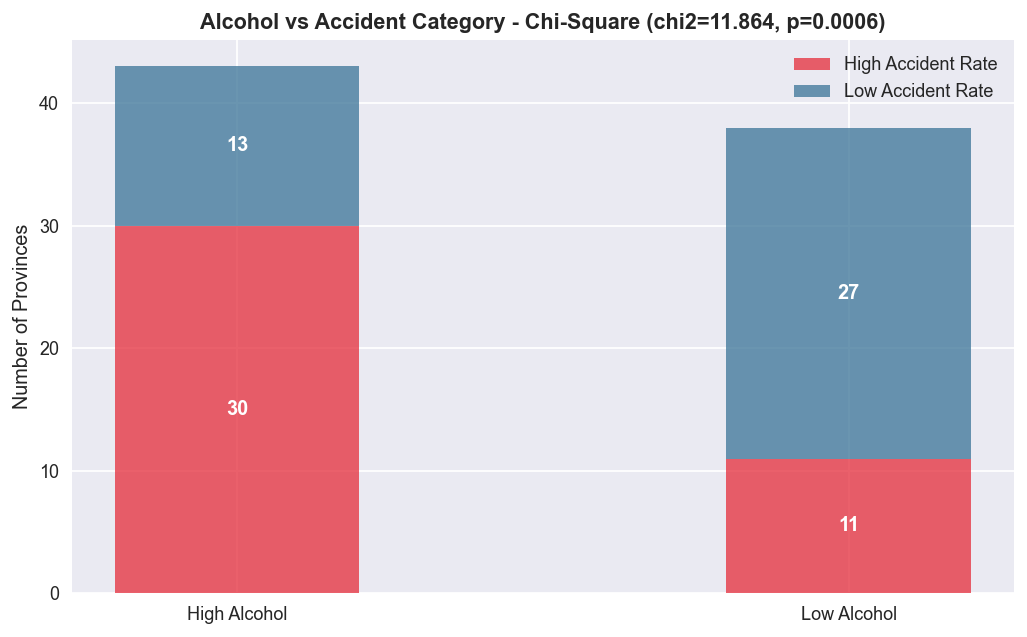

In [56]:
# Binary classification of each province on both dimensions
# Using the median as cut-off ensures a 50/50 split on each variable,
# which maximises statistical power for the chi-square test.

median_acc = df['acc_per_100k'].median()
median_alc = df['alcohol_rate_pct'].median()

df['acc_cat'] = np.where(df['acc_per_100k']     >= median_acc, 'High Accident', 'Low Accident')
df['alc_cat'] = np.where(df['alcohol_rate_pct'] >= median_alc, 'High Alcohol',  'Low Alcohol')

# Build 2x2 contingency table of observed frequencies
contingency = pd.crosstab(
    df['alc_cat'], df['acc_cat'],
    rownames=['Alcohol Category'],
    colnames=['Accident Category']
)
print('Observed contingency table (n=81 provinces):')
display(contingency)

# Chi-square test of independence
# Returns: chi2 statistic, p-value, degrees of freedom, expected freq table
chi2_stat, p_chi2, dof, expected = stats.chi2_contingency(contingency)

# Verify all expected frequencies are >= 5 (required for valid chi-square)
print('\nExpected frequencies (must all be >= 5 for test validity):')
expected_df = pd.DataFrame(expected,
                            index=contingency.index,
                            columns=contingency.columns).round(2)
display(expected_df)
min_expected = expected.min()
print(f'Minimum expected frequency: {min_expected:.2f}',
      'Valid' if min_expected >= 5 else 'Warning: below 5')

print('\n' + '=' * 65)
print('Hypothesis 6: Chi-Square Test of Independence')
print('-' * 65)
print('H0: Alcohol category and accident rate category are independent')
print('H1: Alcohol category and accident rate category are associated')
print(f'\nTest statistic  chi2 = {chi2_stat:.4f}')
print(f'Degrees of freedom  = {dof}  (= (rows-1) x (cols-1) = 1x1)')
print(f'p-value             = {p_chi2:.4f}')
print(f'Significance level alpha = {alpha}')
if p_chi2 < alpha:
    print(f'\nDecision: REJECT H0 at alpha = {alpha}')
    print('Conclusion: Significant association between alcohol category')
    print('            and accident rate category.')
else:
    print(f'\nDecision: FAIL TO REJECT H0 at alpha = {alpha}')
    print('Conclusion: No significant association between the two categories.')

# Effect size: Cramer's V (0 = no association, 1 = perfect association)
n_total   = contingency.values.sum()
cramers_v = np.sqrt(chi2_stat / (n_total * (min(contingency.shape) - 1)))
print(f"\nEffect size (Cramer's V) = {cramers_v:.3f}")
print('  ->', 'Large' if cramers_v >= 0.5 else ('Medium' if cramers_v >= 0.3 else 'Small'), 'association')
print('=' * 65)

# Stacked bar chart of observed counts
fig, ax = plt.subplots(figsize=(8, 5))
alc_groups = ['High Alcohol', 'Low Alcohol']
high_acc   = [contingency.loc[g, 'High Accident'] for g in alc_groups]
low_acc    = [contingency.loc[g, 'Low Accident']  for g in alc_groups]
x_pos = [0.5, 1.5]
ax.bar(x_pos, high_acc, 0.4, color=ACCENT, alpha=0.8, label='High Accident Rate')
ax.bar(x_pos, low_acc,  0.4, color=BLUE,   alpha=0.8, bottom=high_acc, label='Low Accident Rate')
for xi, ha, la in zip(x_pos, high_acc, low_acc):
    ax.text(xi, ha / 2,       str(ha), ha='center', va='center', fontsize=11, color='white', fontweight='bold')
    ax.text(xi, ha + la / 2,  str(la), ha='center', va='center', fontsize=11, color='white', fontweight='bold')
ax.set_xticks(x_pos); ax.set_xticklabels(alc_groups)
ax.set_ylabel('Number of Provinces', fontsize=11)
ax.set_title(f'Alcohol vs Accident Category - Chi-Square (chi2={chi2_stat:.3f}, p={p_chi2:.4f})',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig13_chisquare_bar.png', bbox_inches='tight')
plt.show()


## 5. Summary of Results

In [57]:
# Consolidated results table and final interpretation

print('=' * 70)
print('SUMMARY OF EDA & HYPOTHESIS TESTING RESULTS')
print('=' * 70)

print('\nEXPLORATORY DATA ANALYSIS')
print('-' * 40)
top5 = df.nlargest(5, 'acc_per_100k')['province'].tolist()
bot3 = df.nsmallest(3, 'acc_per_100k')['province'].tolist()
print(f"  Total 2025 injury/fatal accidents : {df_2025['injury_fatal_accidents'].sum():,}")
print(f"  Total 2025 fatalities             : {df_2025['fatalities'].sum():,}")
print(f"  Highest acc/100k provinces        : {', '.join(top5)}")
print(f"  Lowest  acc/100k provinces        : {', '.join(bot3)}")
print(f"  Alcohol rates range               : {df_region['alcohol_rate_pct'].min()}% - {df_region['alcohol_rate_pct'].max()}%")

print('\nHYPOTHESIS TEST RESULTS')
print('-' * 70)
print(f"  {'Test':<35} {'Statistic':<18} {'p-value':<10} Decision")
print(f"  {'-'*35} {'-'*18} {'-'*10} {'-'*20}")

results = [
    ('H1 Independent T-test',   f't = {t_stat:.3f}',     p_ttest,  'one-tail'),
    ('H2 One-Way ANOVA',        f'F = {f_stat:.3f}',     p_anova,  'two-tail'),
    ('H3 Mann-Whitney U',       f'U = {u_stat:.0f}',     p_mw,     'one-tail'),
    ('H4 Kruskal-Wallis',       f'H = {kw_stat:.3f}',    p_kw,     'two-tail'),
    ('H5 Wilcoxon Signed-Rank', f'W = {w_stat:.0f}',     p_wilcox, 'two-tail'),
    ('H6 Chi-Square',           f'chi2 = {chi2_stat:.3f}', p_chi2, 'two-tail'),
]
for name, stat, pv, tail in results:
    decision = 'REJECT H0' if pv < alpha else 'FAIL TO REJECT H0'
    print(f'  {name:<35} {stat:<18} p={pv:.4f}   -> {decision}')

print('\nINTERPRETATION')
print('-' * 40)
print('  H1-H4 and H6 all examine the alcohol-accident relationship.')
print('  Results consistently show: higher alcohol consumption is associated')
print('  with higher traffic accident rates across Turkish provinces/regions.')
print('  H5 examines year-over-year trend (not alcohol), using Q1x4 projection.')
print('  Correlation != causation. Confounders: urbanisation, tourism,')
print('  road infrastructure, speed enforcement, self-reporting bias.')

print('\nLIMITATIONS')
print('-' * 40)
print('  Alcohol data at IBBS1 level only (n=12) -- ecological fallacy risk.')
print('  Temporal gap: 2022 alcohol data vs 2025 accident data.')
print('  Tourist provinces (Mugla, Antalya) have inflated accident rates.')
print('  Q1x4 projection understates 2026 annual total (summer peak effect).')
print('=' * 70)


SUMMARY OF EDA & HYPOTHESIS TESTING RESULTS

EXPLORATORY DATA ANALYSIS
----------------------------------------
  Total 2025 injury/fatal accidents : 288,253
  Total 2025 fatalities             : 2,541
  Highest acc/100k provinces        : Mugla, Osmaniye, Hatay, Nevsehir, Burdur
  Lowest  acc/100k provinces        : Hakkari, Mus, Sirnak
  Alcohol rates range               : 4.7% - 19.8%

HYPOTHESIS TEST RESULTS
----------------------------------------------------------------------
  Test                                Statistic          p-value    Decision
  ----------------------------------- ------------------ ---------- --------------------
  H1 Independent T-test               t = 6.026          p=0.0000   -> REJECT H0
  H2 One-Way ANOVA                    F = 13.370         p=0.0000   -> REJECT H0
  H3 Mann-Whitney U                   U = 28             p=0.0660   -> FAIL TO REJECT H0
  H4 Kruskal-Wallis                   H = 19.441         p=0.0001   -> REJECT H0
  H5 Wilcoxon S